# Prosody-Syntax Distributional Analysis

This notebook builds a co-occurrence matrix of (lemma, POS) tags against a mix of
**syntactic** and **prosodic** features extracted from the SUD-French-Rhapsodie
treebank. From that matrix we derive three parallel views — syntactic-only,
prosodic-only, and combined — and use each to compute:

1. **Similarity scores** between lexical units
2. A **per-unit purity / entropy / rival-category** score
3. A **category-level transition matrix** (how categories bleed into each other)
4. **Bridge words** — units whose neighbourhood pulls them toward a different POS
5. **Pulling features** — the features responsible for that pull
6. A global **weighted-average stability** for each feature space: syntactic, prosodic or both

The key cleanup vs. the original notebook: every downstream analysis takes a
`space` selector ∈ `{"syntactic", "prosodic_syntactic", "prosody_pure", "combined",
"prosodic_foot", "prosodic_group", "prosodic_package", "prosodic_period",
"prosodic_all_levels"}`, so swapping feature
spaces is a one-line change.

In [97]:
import sys
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from scipy.stats import entropy
from sklearn.metrics.pairwise import cosine_similarity

# ── Paths ──────────────────────────────────────────────────────────────────
TOD_PATH      = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod"
GREX_PATH     = "/Users/madalina/Documents/M2TAL/stage/grex/grex2"
TREEBANK_PATH = "/Users/madalina/Documents/PHD/code/data/SUD_French-Rhapsodie/prosody_no_punct.conllu"
# TREEBANK_PATH = "/Users/madalina/Documents/PHD/code/data/pSUD_Naija-NSC"
PATTERNS_FILE = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes_prosody.txt"

GREW_PATTERN      = "pattern{X[upos<>PUNCT]}"

# ── Bring third-party packages onto the path ───────────────────────────────
for p in (TOD_PATH, GREX_PATH):
    if p not in sys.path:
        sys.path.insert(1, p)

import pyximport
pyximport.install()

import grewpy
from grewpy import Corpus, CorpusDraft, Request

import tod.corpus  # noqa: F401  (registers handlers; keep import)

import grex.data           # noqa: F401
import grex.utils
import grex.features       # noqa: F401
import grex.data_prosody

grewpy.set_config("sud")


In [98]:
# ── Drop entirely: redundant, unreliable, or too fine-grained ─────────────
FEATURES_TO_DROP = {
    'MeanF0',           # use SemitonesFromUtteranceMean instead (speaker-normalised)
    'MeanF0Step',       # threshold artefact, not a prosodic observation
    'AvgAmplitude',     # recording-condition-dependent
    'MaxAmplitude',     # same
    'SylForm',          # phonetic transcription, too fine-grained
    'AlignBegin',       # timing offset, not linguistic
    'AlignEnd',         # timing offset, not linguistic
    'pauseID',          # identifier, not a feature
    # Before*/Next* equivalents of dropped features:
    'BeforeMeanF0', 'BeforeMeanF0Step', 'BeforeAvgAmplitude',
    'NextMeanF0',   'NextMeanF0Step',   'NextAvgAmplitude',
    'Semiton', 'Overlap', 'Loc', 'Glo', 'Backchannel',
    "AvgAmplitudeNormalized", "Nucleus", "Onset", "MeanF0GlobalZscore", "MeanF0LocalZscore", "MeanF0Normalized"
}

# ── Bin into 3 quantile-based categories ──────────────────────────────────
# Note: Duration appears in TWO units in the data:
#   - syllable subnodes: integer ms     (e.g. 289, 167)
#   - pause nodes:       float seconds  (e.g. 0.2695, 0.3328)
# We normalise to ms before binning — see `_normalise_duration` below.
FEATURES_TO_BIN = {
    'SemitonesFromUtteranceMean',
    'Duration',
    'BeforeSemitonesFromUtterance',
    'NextSemitonesFromUtterance',
    'BeforeDuration',
    'NextDuration',
    'BeforeSemiton',
    'NextSemiton',
    'NextSemitonsFromUtterance',
    'NextBreakLength',
    'AvgAmplitudeGlobalZscore', # naija
    # naija
    "DurationGlobalZscore" # naija
}

BIN_LABELS = {
    'SemitonesFromUtteranceMean':   ['F0_low',       'F0_mid',       'F0_high'],
    'Duration':                     ['Dur_short',    'Dur_mid',      'Dur_long'],
    'BeforeSemitonesFromUtterance': ['BeforeF0_low', 'BeforeF0_mid', 'BeforeF0_high'],
    'NextSemitonesFromUtterance':   ['NextF0_low',   'NextF0_mid',   'NextF0_high'],
    'NextBreakLength':              ['NextBreak_short', 'NextBreak_mid', 'NextBreak_long'],
    
}


In [99]:
# ── SLAM3 contour decomposition ───────────────────────────────────────────
# The *Tone features (FootTone, GroupTone, PackageTone, Period_tone) encode
# pitch contours compositionally:
#
#     [start_pitch][end_pitch]            -- no salient peak (2 chars)
#     [start_pitch][end_pitch][peak][tier] -- with salient peak (4 chars)
#
# pitch ∈ {L, l, m, h, H}  (5 ordinal levels: very low → very high)
# tier  ∈ {1, 2, 3}        (which syllabic tier carries the peak)
# Plus the special atomic value 'Pause'.
#
# Treating these as opaque strings gives ~300 sparse one-hot columns per
# *Tone feature. Decomposing into {start, end, peak, tier, has_peak,
# direction, magnitude} yields ~5 dense sub-features per token instead.

SLAM_TONE_FEATURES = {'FootTone', 'GroupTone', 'PackageTone', 'Period_tone', 'Period', 'PeriodTone'}

# Ordinal mapping used to derive direction & magnitude.
_PITCH_LEVELS = {'L': 1, 'l': 2, 'm': 3, 'h': 4, 'H': 5}
_TIERS = {'1', '2', '3'}


def _parse_slam(label):
    """Parse a SLAM3 contour string into its components.

    Returns a dict {pause, start, end, peak, tier} or None if the label
    doesn't match the SLAM3 grammar (silently skipped downstream).
    """
    if label == 'Pause':
        return {'pause': True, 'start': None, 'end': None,
                'peak': None, 'tier': None}

    if (len(label) == 2
            and label[0] in _PITCH_LEVELS and label[1] in _PITCH_LEVELS):
        return {'pause': False, 'start': label[0], 'end': label[1],
                'peak': None, 'tier': None}

    if (len(label) == 4
            and label[0] in _PITCH_LEVELS and label[1] in _PITCH_LEVELS
            and label[2] in _PITCH_LEVELS and label[3] in _TIERS):
        return {'pause': False, 'start': label[0], 'end': label[1],
                'peak': label[2], 'tier': label[3]}

    return None


def _slam_subfeatures(prefix, label):
    """Yield 'sub-feature=value' strings derived from a SLAM3 contour label.

    `prefix` is the path up to and including the *Tone name,
    e.g. 'node:X:child:GroupTone'. Sub-features become
    'node:X:child:GroupTone:start=H', 'node:X:child:GroupTone:direction=rise', …
    """
    parsed = _parse_slam(label)
    if parsed is None:
        return

    if parsed['pause']:
        yield f"{prefix}:pause=True"
        return

    s, e = parsed['start'], parsed['end']
    yield f"{prefix}:start={s}"
    yield f"{prefix}:end={e}"

    # Direction & magnitude on the ordinal pitch scale.
    delta = _PITCH_LEVELS[e] - _PITCH_LEVELS[s]
    if delta > 0:
        direction = 'rise'
    elif delta < 0:
        direction = 'fall'
    else:
        direction = 'flat'
    yield f"{prefix}:direction={direction}"
    yield f"{prefix}:magnitude={abs(delta)}"

    if parsed['peak'] is not None:
        yield f"{prefix}:has_peak=True"
        yield f"{prefix}:peak={parsed['peak']}"
        yield f"{prefix}:tier={parsed['tier']}"
    else:
        yield f"{prefix}:has_peak=False"

In [100]:
def _normalise_duration(value_str):
    """Convert a Duration string to milliseconds regardless of source node type.

    Syllable subnodes store ms (e.g. '289'); pause nodes store seconds
    (e.g. '0.2695'). Heuristic: values < 10 are seconds. A literal 0.0 means
    'missing' (e.g. overlap nodes) → returns None.
    """
    try:
        v = float(value_str)
    except (ValueError, TypeError):
        return None
    if v == 0.0:
        return None
    return v * 1000 if v < 10 else v


def _is_sentinel(value_str):
    """True for the '0.0' sentinel that overlap / missing pause nodes carry.

    Without this guard, those zeros would be binned as F0_low rather than
    silently dropped.
    """
    try:
        return float(value_str) == 0.0
    except (ValueError, TypeError):
        return False


def _feature_name(key):
    """Bare feature name from a path-like key, e.g. ('node','X','child','Duration') → 'Duration'."""
    return key[-1]


In [101]:
def collect_continuous_values(all_data_items):
    """Walk every (lex_unit, match, features) triple and collect raw float
    values for each feature in FEATURES_TO_BIN.

    Returns: {feature_name: [float, ...]}
    """
    collector = {f: [] for f in FEATURES_TO_BIN}

    for _, _, features in all_data_items:
        for key, value in features.items():
            fname = _feature_name(key)
            if fname not in FEATURES_TO_BIN:
                continue
            # `value` is a string for own/parent/prev/next, or a set of strings
            # for child (a node can have multiple syllables).
            values = value if isinstance(value, set) else {value}
            for v in values:
                if fname == 'Duration':
                    norm = _normalise_duration(v)
                    if norm is not None:
                        collector['Duration'].append(norm)
                elif not _is_sentinel(v):
                    try:
                        collector[fname].append(float(v))
                    except (ValueError, TypeError):
                        pass
    return collector


def compute_thresholds(collector, n_bins=3):
    """Quantile boundaries (interior only) per feature.

    Returns: {feature_name: [boundary_1, boundary_2, ...]}
    """
    thresholds = {}
    for fname, values in collector.items():
        if not values:
            continue
        arr = np.array(values)
        quantiles = np.linspace(0, 1, n_bins + 1)[1:-1]
        thresholds[fname] = np.quantile(arr, quantiles).tolist()
    return thresholds


In [102]:
def _bin_value(fname, value_str, thresholds):
    """Continuous string → bin label. Returns None for sentinels / unknowns."""
    if fname not in thresholds or _is_sentinel(value_str):
        return None

    if fname == 'Duration':
        v = _normalise_duration(value_str)
    else:
        try:
            v = float(value_str)
        except (ValueError, TypeError):
            return None

    if v is None:
        return None

    bounds = thresholds[fname]
    labels = BIN_LABELS.get(fname, [f'{fname}_Q1', f'{fname}_Q2', f'{fname}_Q3'])
    for i, b in enumerate(bounds):
        if v <= b:
            return labels[i]
    return labels[-1]


def format_features(features, thresholds):
    """Turn a feature dict into a list of 'k1:k2:...:kn=value' strings.

    Continuous features are binned; dropped features are skipped.
    """
    result = []
    for key, value in features.items():
        fname = _feature_name(key)
        prefix = ':'.join(key)

        if fname in FEATURES_TO_DROP:
            continue

        if fname in FEATURES_TO_BIN:
            values = value if isinstance(value, set) else {value}
            for v in values:
                label = _bin_value(fname, v, thresholds)
                if label is not None:
                    result.append(f"{prefix}={label}")
            continue
        
        # if fname == 'Period':
        #     # Strip *, -, and prefix/suffix markers to collapse 16 values down to 4.
        #     for v in values:
        #         cleaned = v.strip('*-')
        #         result.append(f"{prefix}={cleaned}")
        #     # If you want to preserve the pause-adjacency information as its own
        #     # feature, add a boolean:
        #     if any('*' in v or '-' in v for v in values):
        #         result.append(f"{prefix}_pause_adjacent=True")
        #     continue
        
        # SLAM3 contour features: decompose into structural sub-features.
        if fname in SLAM_TONE_FEATURES:
            values = value if isinstance(value, set) else {value}
            for v in values:
                result.extend(_slam_subfeatures(prefix, v))
            continue


        # Categorical: keep as-is.
        if isinstance(value, set):
            for v in value:
                result.append(f"{prefix}={v}")
        else:
            result.append(f"{prefix}={value}")

    return result


def _filter_features(features, excluded_patterns=None, included_patterns=None):
    """Regex-based include/exclude filter over a list of feature strings."""
    import re
    out = []
    for feature in features:
        if excluded_patterns and any(re.search(p, feature) for p in excluded_patterns):
            continue
        if included_patterns and not any(re.search(p, feature) for p in included_patterns):
            continue
        out.append(feature)
    return out


In [103]:
corpus = grewpy.Corpus(TREEBANK_PATH)
draft  = grewpy.CorpusDraft(corpus)

all_matches = corpus.search(
    grewpy.Request(GREW_PATTERN)
        .without("X[InIdiom=Yes]")
        .without("X[Idiom=Yes]")
        .without("X[InTitle=Yes]")
        .without("X[Title=Yes]")
        .without("X[Scrap=Yes]")
        .without("X[Foreign]")
        .without("X[Lang]")
        .without("X-[fixed]->Y")
        .without("Y-[flat:name]->X")
        .without("Y-[goeswith]->X"),
    clustering_keys=["X.form"],
)

# Drop lemmas with fewer than 10 occurrences.
# matches = {k: v for k, v in all_matches.items() if len(v) > 10}
matches=all_matches

# sent_id → {node_id: features}
sent_id_to_sentence = {
    draft[i].meta["sent_id"]: draft[i].features for i in range(len(draft))  # type: ignore
}

print(f"Lemmas after frequency filter: {len(matches)}")


Lemmas after frequency filter: 4567


In [104]:
# Re-key by (lemma, POS). Use ExtPos when present (e.g. '%' has upos=SYM but
# ExtPos=NOUN, and we want NOUN). Otherwise fall back to upos.
match_upos = {}
for lemma, occurrences in matches.items():
    for m in occurrences:
        sent_id = m["sent_id"]
        node_id = str(m["matching"]["nodes"]["X"])
        sentence_features = sent_id_to_sentence.get(sent_id)
        if sentence_features is None or node_id not in sentence_features:
            continue
        token_features = sentence_features[node_id]
        if "ExtPos" in token_features:
            pos = token_features["ExtPos"]
        elif "upos" in token_features:
            pos = token_features["upos"]
        else:
            print(f"WARNING: lemma '{lemma}' in '{sent_id}' has no upos.")
            continue
        match_upos.setdefault((lemma, pos), []).append(m)

# Filter again post-split: a lemma may have passed at the lemma level but
# split into rare (lemma, POS) pairs.
# match_upos = {k: v for k, v in match_upos.items() if len(v) > 10}

print(f"(lemma, POS) units after frequency filter: {len(match_upos)}")


(lemma, POS) units after frequency filter: 4880


In [105]:
# Load the feature template config and run feature extraction over every match.
with open(PATTERNS_FILE) as f:
    config = yaml.load(f, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(
    config["features"], templates=templates,
)

all_data_items = []
for lex_unit, mts in match_upos.items():
    for match in mts:
        feats = grex.data_prosody.extract_features(draft, match, feature_predicate)
        all_data_items.append((lex_unit, match, feats))

print(f"Total (lex_unit, match, features) triples: {len(all_data_items)}")


Total (lex_unit, match, features) triples: 33175


In [226]:
# Compute corpus-wide quantile thresholds, then format every match's features
# (binning the continuous ones, dropping the unwanted ones).
collector  = collect_continuous_values(all_data_items)
thresholds = compute_thresholds(collector, n_bins=3)

print("Computed thresholds:")
for fname, bounds in thresholds.items():
    labels = BIN_LABELS.get(fname, ['Q1', 'Q2', 'Q3'])
    print(
        f"  {fname}: <{bounds[0]:.3f} → {labels[0]} | "
        f"<{bounds[1]:.3f} → {labels[1]} | ≥{bounds[1]:.3f} → {labels[2]}"
    )

# Drop 'own' features (the focused node's own attributes — they trivially
# determine its category and would dominate similarity).
EXCLUDED_FEATURE_PATTERNS = [# Own features that would trivially recover POS or aren't prosodic
    'upos', 'lemma', 'form',
    'rel_shallow', 'deprel',
    'Case', 'Definite', 'Gender', 'Mood',
    'Number', 'NumType', 'Person', 'Polarity',
    'Poss', 'PronType', 'Reflex', 'Tense',
    'VerbForm', 'Voice',
    'Number[lex]', 'Person[lex]',
    'Gender[ctxt]', 'Number[ctxt]',
    'ExtPos', 'Foreign', 'Lang', 'Emph',
    'HasSpokenGender', 'HasSpokenNumber',
    'AlignBegin', 'AlignEnd', 'SylForm', 'SpaceAfter',
    # Unmeasurable slope
    'Slope=X',
    # Fused: rare and per-syllable, drops signal-to-noise
    'Fused=Yes',
    # Redundant local slope (keep the Glo scope)
    ':Slope=',
    # Morphological features of dependents — clutter the syntactic space
    'own:Filler=', "Token2=", "rel_deep=", "__MISC__Rel=", "TypePara=", "TypeInherited=", "Truncated=", "Subject=", "Token3", "Token4", "ProminenceFinal=0", "ProminenceInitial=0", "UtteranceMeanF0=0.0",
    "IU", "nucleus", "Layer", "Filler=", "Shared",     
    'ExtPos', "Loc=", "direction=flat", "has_peak=False", 
    # "FootTone:pause", "GroupTone:pause", "PackageTone:pause", "Period_tone:pause", "ProminenceFinal=Pause", "ProminenceInitial=Pause",

                             "AvgAmplitudeLocalZscore", "DurationLocalZscore", "MaxAmplitudeLocalZscore", "DurationNormalized", "MaxAmplitudeGlobalZscore", 
                             "Nucleus", "Onset", "MeanF0GlobalZscore", "MeanF0LocalZscore", "MeanF0Normalized", "MaxAmplitudeNormalized", "Coda"
                             ]

data = {k: [] for k in match_upos}
for lex_unit, _, features in all_data_items:
    formatted = _filter_features(
        format_features(features, thresholds),
        excluded_patterns=EXCLUDED_FEATURE_PATTERNS,
    )
    data[lex_unit].append(formatted)


Computed thresholds:
  NextBreakLength: <0.283 → NextBreak_short | <0.530 → NextBreak_mid | ≥0.530 → NextBreak_long
  SemitonesFromUtteranceMean: <-1.278 → F0_low | <0.529 → F0_mid | ≥0.529 → F0_high
  Duration: <133.000 → Dur_short | <199.000 → Dur_mid | ≥199.000 → Dur_long


In [251]:
# Build index lookups. These are used everywhere downstream.
unique_lemma    = sorted(set(data))
unique_features = sorted({feat for lists in data.values() for fs in lists for feat in fs})

idx2feature = {i: feat for i, feat in enumerate(unique_features)}
feature2idx = {feat: i for i, feat in idx2feature.items()}
idx2lexunit = {i: feat for i, feat in enumerate(unique_lemma)}
lexunit2idx = {feat: i for i, feat in idx2lexunit.items()}

print(f"Lexical units: {len(idx2lexunit)} | features: {len(idx2feature)}")


Lexical units: 4880 | features: 11615


In [252]:
co_occurrence_matrix = np.zeros((len(idx2lexunit), len(idx2feature)))
for lex_unit, feature_lists in data.items():
    for feature_list in feature_lists:
        for feature in feature_list:
            co_occurrence_matrix[lexunit2idx[lex_unit], feature2idx[feature]] += 1

# Occurrence count per unit, aligned to row order.
n_occ = np.array([len(data[idx2lexunit[i]]) for i in range(len(idx2lexunit))],
                 dtype=float)

occurrence_matrix = np.divide(
    co_occurrence_matrix,
    n_occ[:, np.newaxis],
    out=np.zeros_like(co_occurrence_matrix),
    where=n_occ[:, np.newaxis] != 0,
)

feature_matrix = occurrence_matrix


In [253]:
# ── Column-frequency filter ───────────────────────────────────────────────
# Drop feature columns that are non-zero on fewer than MIN_LEXUNITS lexical
# units. Such columns contribute mostly noise to cosine similarity (they look
# like spurious axes of variation between the few units that happen to use
# them) and bloat the matrix.
#
# Cosine similarity is scale-invariant, so we don't renormalise rows after
# dropping columns — within-row ratios are preserved.
MIN_LEXUNITS = 10

col_nonzero_per_lexunit = (co_occurrence_matrix > 0).sum(axis=0)
keep_cols = col_nonzero_per_lexunit >= MIN_LEXUNITS

n_before = feature_matrix.shape[1]
co_occurrence_matrix = co_occurrence_matrix[:, keep_cols]
feature_matrix       = feature_matrix[:, keep_cols]

# Rebuild the index lookups so they stay aligned with the matrix.
kept_features = [idx2feature[i] for i in range(n_before) if keep_cols[i]]
idx2feature   = {i: f for i, f in enumerate(kept_features)}
feature2idx   = {f: i for i, f in idx2feature.items()}

print(f"Dropped {n_before - int(keep_cols.sum())} columns "
      f"non-zero on <{MIN_LEXUNITS} lexical units.")
print(f"Remaining features: {int(keep_cols.sum())} / {n_before}")

Dropped 10692 columns non-zero on <10 lexical units.
Remaining features: 923 / 11615


In [254]:
# ── Feature-space masks ───────────────────────────────────────────────────
# Each space is a subset of columns of `feature_matrix`. Substring matching on
# the feature name decides which mask a column falls into — e.g. the marker
# 'Foot' catches 'Foot=Begin', 'FootTone:start=H', 'FootType=Strong' alike.
#
# Spaces:
#   syntactic          — every column NOT in PROSODIC_MARKERS (POS, deprel,
#                        morphology, IU/Nucleus position, …). Includes syntactic
#                        features attached to any position (parent, child,
#                        prev token, next token).
#   prosodic_syntactic — every column in PROSODIC_MARKERS. This mixes prosody
#                        with the syntactic environment: prosodic features
#                        attached to the token's parent, dependents, and
#                        linear neighbours count as prosodic here even though
#                        they involve the syntactic tree to locate them.
#   prosody_pure       — only prosodic features attached to the lex unit's own
#                        syllables (childSyl1, childSyl2, …) and the syllables
#                        immediately before and after (prevSyl, nextSyl) and the node immediately before, after and own. No
#                        features from the syntactic environment. This is the
#                        strictest "prosody without syntax" view.
#   prosodic_foot      — Foot / FootTone / FootType only
#   prosodic_group     — Group / GroupTone / RhythmGroup only
#   prosodic_package   — Package / PackageTone / Package_type only
#   prosodic_period    — Period / Period_tone only
#   prosodic_all_levels— union of the four per-level spaces above (i.e.
#                        structural prosodic only, no syllable acoustics)
#   combined           — every column

PROSODIC_MARKERS = (
    # syllable-level / continuous acoustic
    'childSyl', 'prevSyl', 'nextSyl',
    'Slope', 'Glo', 'Loc', 'Duration',
    'PitchRange', 'AvgHeight', 'Semiton',
    'F0', 'Fused',
    # token-level prosodic structural annotations
    'Foot', 'Group', 'Package', 'Period',
    'Prominence', 'Hesitation', 'RhythmGroup', 'NextBreakLength', 'IU', 'Nucleus'
)

# Markers for the strictest "prosody only" view: features on the lex unit's
# own syllables and its immediate prev/next syllable. Everything else — parent
# tokens, dependent tokens, prev/next tokens — is excluded, even if those
# features are themselves prosodic.
PROSODY_PURE_MARKERS = ('own', 'childSyl', 'prevSyl', 'nextSyl', 'prev:', 'next:',)

# Per-level markers for the prosodic ablation views. Substring matching
# naturally catches the *Tone:* and *Type variants:
#   'Foot'    → Foot, FootTone, FootType
#   'Group'   → Group, GroupTone, RhythmGroup
#   'Package' → Package, PackageTone, Package_type
#   'Period'  → Period, Period_tone
LEVEL_MARKERS = {
    'foot':    ('Foot',),
    'group':   ('Group',),
    'package': ('Package',),
    'period':  ('Period',),
}


def _mask_for(markers):
    return np.array([
        any(p in feat for p in markers)
        for feat in idx2feature.values()
    ])


prosodic_mask     = _mask_for(PROSODIC_MARKERS)
syntactic_mask    = ~prosodic_mask
prosody_pure_mask = _mask_for(PROSODY_PURE_MARKERS)
level_masks       = {lvl: _mask_for(m) for lvl, m in LEVEL_MARKERS.items()}
all_levels_mask   = np.any(np.stack(list(level_masks.values())), axis=0)

print(f"Syntactic           features: {int(syntactic_mask.sum())}")
print(f"Prosodic_syntactic  features: {int(prosodic_mask.sum())}")
print(f"Prosody_pure        features: {int(prosody_pure_mask.sum())}")
for lvl, m in level_masks.items():
    print(f"  prosodic_{lvl:<7s} features: {int(m.sum())}")
print(f"  prosodic_all_levels features: {int(all_levels_mask.sum())}")

# Cosine similarities for each space. `combined` uses the full matrix.
similarities = {
    "syntactic":           cosine_similarity(feature_matrix[:, syntactic_mask]),
    "prosodic_syntactic":  cosine_similarity(feature_matrix[:, prosodic_mask]),
    "prosody_pure":        cosine_similarity(feature_matrix[:, prosody_pure_mask]),
    # "prosodic_foot":       cosine_similarity(feature_matrix[:, level_masks['foot']]),
    # "prosodic_group":      cosine_similarity(feature_matrix[:, level_masks['group']]),
    # "prosodic_package":    cosine_similarity(feature_matrix[:, level_masks['package']]),
    # "prosodic_period":     cosine_similarity(feature_matrix[:, level_masks['period']]),
    # "prosodic_all_levels": cosine_similarity(feature_matrix[:, all_levels_mask]),
    "combined":            cosine_similarity(feature_matrix),
}

SPACE_MASKS = {
    "syntactic":           syntactic_mask,
    "prosodic_syntactic":  prosodic_mask,
    "prosody_pure":        prosody_pure_mask,
    # "prosodic_foot":       level_masks["foot"],
    # "prosodic_group":      level_masks["group"],
    # "prosodic_package":    level_masks["package"],
    # "prosodic_period":     level_masks["period"],
    # "prosodic_all_levels": all_levels_mask,
    "combined":            None,
}

Syntactic           features: 9
Prosodic_syntactic  features: 914
Prosody_pure        features: 599
  prosodic_foot    features: 195
  prosodic_group   features: 195
  prosodic_package features: 200
  prosodic_period  features: 135
  prosodic_all_levels features: 725


In [255]:
# features2pop = [618, 512, 727, 925, 4, 5, 40, 51, 52, 95, 96, 117, 153, 154, 155, 156, 196, 201, 306, 307, 
#                 342, 353, 354, 397, 398, 418, 454, 455, 456, 496, 501, 192, 197, 492, 497, 709, 713, 906, 910,   ]
# for f in features2pop:
#     try:
#         idx2feature.pop(f, None)
#     except KeyError:
#         print(f"Feature index {f} not found in idx2feature.")
    
prosodic_pure_features = [
    feat for i, feat in idx2feature.items()
    if prosody_pure_mask[i]
]

print(f"Prosodic_pure features: {len(prosodic_pure_features)}")
for feat in prosodic_pure_features:
    print(feat)

Prosodic_pure features: 599
node:X:childSyl1:AvgHeightGlo=H
node:X:childSyl1:AvgHeightGlo=L
node:X:childSyl1:AvgHeightGlo=M
node:X:childSyl1:Duration=Dur_long
node:X:childSyl1:Duration=Dur_mid
node:X:childSyl1:Duration=Dur_short
node:X:childSyl1:PitchRangeGlo=H
node:X:childSyl1:PitchRangeGlo=L
node:X:childSyl1:PitchRangeGlo=M
node:X:childSyl1:SemitonesFromUtteranceMean=F0_high
node:X:childSyl1:SemitonesFromUtteranceMean=F0_low
node:X:childSyl1:SemitonesFromUtteranceMean=F0_mid
node:X:childSyl1:SlopeGlo=Fall
node:X:childSyl1:SlopeGlo=Flat
node:X:childSyl1:SlopeGlo=Rise
node:X:childSyl2:AvgHeightGlo=H
node:X:childSyl2:AvgHeightGlo=L
node:X:childSyl2:AvgHeightGlo=M
node:X:childSyl2:Duration=Dur_long
node:X:childSyl2:Duration=Dur_mid
node:X:childSyl2:Duration=Dur_short
node:X:childSyl2:PitchRangeGlo=H
node:X:childSyl2:PitchRangeGlo=L
node:X:childSyl2:PitchRangeGlo=M
node:X:childSyl2:SemitonesFromUtteranceMean=F0_high
node:X:childSyl2:SemitonesFromUtteranceMean=F0_low
node:X:childSyl2:Semit

In [112]:
def find_own_only_features(feature_list):
    # Split each line into its components
    own_features = set()
    prev_features = set()
    next_features = set()

    for line in feature_list:
        if line.startswith("node:X:own:"):
            feature = line.split("node:X:own:")[1]
            own_features.add(feature)
        elif line.startswith("node:X:prev:"):
            feature = line.split("node:X:prev:")[1]
            prev_features.add(feature)
        elif line.startswith("node:X:next:"):
            feature = line.split("node:X:next:")[1]
            next_features.add(feature)

    # Find features only in own
    only_own = own_features - (prev_features | next_features)
    return sorted(only_own)

# Example usage:
# features = [ "node:X:own:Foot=Begin", "node:X:prev:Foot=Begin", ... ]
only_own = find_own_only_features(prosodic_pure_features)
print(only_own)

[]


In [113]:
prosodic_syntactic_features = [
    feat for i, feat in idx2feature.items()
    if prosodic_mask[i]
]
print(f"Prosodic_syntactic features: {len(prosodic_syntactic_features)}")
for feat in prosodic_syntactic_features:
    print(feat)

Prosodic_syntactic features: 889
node:X:child:Foot=Begin
node:X:child:Foot=In
node:X:child:Foot=Last
node:X:child:Foot=Unique
node:X:child:FootTone:direction=fall
node:X:child:FootTone:direction=rise
node:X:child:FootTone:end=H
node:X:child:FootTone:end=L
node:X:child:FootTone:end=h
node:X:child:FootTone:end=l
node:X:child:FootTone:end=m
node:X:child:FootTone:has_peak=True
node:X:child:FootTone:magnitude=0
node:X:child:FootTone:magnitude=1
node:X:child:FootTone:magnitude=2
node:X:child:FootTone:magnitude=3
node:X:child:FootTone:magnitude=4
node:X:child:FootTone:peak=H
node:X:child:FootTone:peak=L
node:X:child:FootTone:peak=h
node:X:child:FootTone:peak=l
node:X:child:FootTone:peak=m
node:X:child:FootTone:start=H
node:X:child:FootTone:start=L
node:X:child:FootTone:start=h
node:X:child:FootTone:start=l
node:X:child:FootTone:start=m
node:X:child:FootTone:tier=1
node:X:child:FootTone:tier=2
node:X:child:FootTone:tier=3
node:X:child:FootType=Strong
node:X:child:FootType=Weak
node:X:child:Foo

In [256]:
# Global category frequencies — denominator of P_norm.
all_pos = [lu[1] for lu in idx2lexunit.values()]

total_pos_count = len(all_pos)
category_freqs = {cat: count / total_pos_count for cat, count in Counter(all_pos).items()}

def compute_scores(similarity, idx2lexunit, category_freqs,
                   sim_threshold=0.7, max_neighbours=20):
    """For every lexical unit, return purity / entropy / rival-category metrics
    based on the given similarity matrix.

    Returns: {(lemma, POS): {"purity", "entropy", "rival_category", "rival_weight_ratio"}}
    """
    scores = {}

    for idx, lex_unit in idx2lexunit.items():
        current_category = lex_unit[1]

        # 1. Top-k neighbours above similarity threshold (excluding self).
        candidate_idx = np.where(similarity[idx] >= sim_threshold)[0]
        neighbours = sorted(
            [i for i in candidate_idx if i != idx],
            key=lambda i: similarity[idx][i],
            reverse=True,
        )[:max_neighbours]

        if not neighbours:
            continue

        # 2. Sum similarity weight per category.
        category_weights = {}
        purity_bottom = 0.0
        for n_idx in neighbours:
            n_cat = idx2lexunit[n_idx][1]
            w = similarity[idx][n_idx]
            purity_bottom += w
            category_weights[n_cat] = category_weights.get(n_cat, 0) + w

        # 3. P_norm = (raw share) / (global frequency), then renormalise to sum to 1.
        norm_weights = {
            cat: (w / purity_bottom) / category_freqs[cat]
            for cat, w in category_weights.items()
        }
        total = sum(norm_weights.values())
        p_norm = {cat: v / total for cat, v in norm_weights.items()}

        # 4. Purity & entropy.
        purity_score  = p_norm.get(current_category, 0.0)
        entropy_score = entropy(list(p_norm.values()))

        # 5. Strongest non-self category.
        rival_cat = None
        rival_p   = 0.0
        for cat, p in p_norm.items():
            if cat != current_category and p > rival_p:
                rival_p   = p
                rival_cat = cat

        scores[lex_unit] = {
            "purity":             purity_score,
            "entropy":            entropy_score,
            "rival_category":     rival_cat,
            "rival_weight_ratio": rival_p,
        }

    return scores


In [257]:
# Compute scores for all three feature spaces in one pass. Pick whichever you
# want for downstream analysis.
scores_by_space = {
    space: compute_scores(sim, idx2lexunit, category_freqs)
    for space, sim in similarities.items()
}

print({space: len(s) for space, s in scores_by_space.items()})


{'syntactic': 4597, 'prosodic_syntactic': 2524, 'prosody_pure': 2996, 'combined': 2557}


In [234]:
# find word with lowest purity and lowest entropy in the prosody_pure space
prosody_pure_scores = scores_by_space["prosody_pure"]
lowest_purity_word = min(prosody_pure_scores.items(), key=lambda x: x[1]["purity"])
lowest_entropy_word = min(prosody_pure_scores.items(), key=lambda x: x[1]["entropy"])
print(f"Lowest purity word: {lowest_purity_word[0]} with purity {lowest_purity_word[1]['purity']}")
print(f"Lowest entropy word: {lowest_entropy_word[0]} with entropy {lowest_entropy_word[1]['entropy']}")

Lowest purity word: ('-moi', 'PRON') with purity 0.0
Lowest entropy word: ('-nous', 'PRON') with entropy 0.0


In [235]:
# show words with purity < 0.5 in the prosody_pure space
low_purity_words = {word: score for word, score in prosody_pure_scores.items() if score["purity"] < 0.5}
print(f"Words with purity < 0.5 in prosody_pure space: {len(low_purity_words)}")
for word, score in low_purity_words.items():
    print(f"{word}: purity={score['purity']}, entropy={score['entropy']}, rival_category={score['rival_category']}, rival_weight_ratio={score['rival_weight_ratio']}")

Words with purity < 0.5 in prosody_pure space: 2578
('-ce', 'PRON'): purity=0.37064219886662136, entropy=1.1516597169178482, rival_category=AUX, rival_weight_ratio=0.4828018028273619
('-dessus', 'NOUN'): purity=0.08741648704281002, entropy=1.3991550756225164, rival_category=AUX, rival_weight_ratio=0.4633293740169245
('-il', 'PRON'): purity=0.10696200135744349, entropy=1.5826638829940458, rival_category=ADP, rival_weight_ratio=0.2965885026780328
('-ils', 'PRON'): purity=0.19195420066015942, entropy=1.057622278133095, rival_category=AUX, rival_weight_ratio=0.5159001144537189
('-là', 'ADV'): purity=0.2809440195609872, entropy=1.2771661954781455, rival_category=PRON, rival_weight_ratio=0.5176355459085403
('-moi', 'PRON'): purity=0.0, entropy=0.6082254747412388, rival_category=ADV, rival_weight_ratio=0.7030875621452588
('-nous', 'PRON'): purity=0.0, entropy=0.0, rival_category=NOUN, rival_weight_ratio=1.0
('-on', 'PRON'): purity=0.18733366179615232, entropy=1.6182639236910095, rival_categor

In [258]:
def build_transition_matrix(similarity, idx2lexunit, category_freqs,
                            sim_threshold=0.7, max_neighbours=20):
    """Square row-stochastic DataFrame indexed by POS category."""
    rows = []

    for idx, lex_unit in idx2lexunit.items():
        current_cat = lex_unit[1]

        candidate_idx = np.where(similarity[idx] > sim_threshold)[0]
        neighbours = sorted(
            [i for i in candidate_idx if i != idx],
            key=lambda i: similarity[idx][i],
            reverse=True,
        )[:max_neighbours]

        if not neighbours:
            continue

        raw_weights = {}
        total_raw_weight = 0.0
        for n_idx in neighbours:
            n_cat = idx2lexunit[n_idx][1]
            sim = similarity[idx][n_idx]
            raw_weights[n_cat] = raw_weights.get(n_cat, 0) + sim
            total_raw_weight += sim

        norm_probs = {
            cat: (w / total_raw_weight) / category_freqs[cat]
            for cat, w in raw_weights.items()
        }
        total = sum(norm_probs.values())
        for cat in norm_probs:
            norm_probs[cat] /= total
            rows.append({"Original": current_cat, "Neighbor": cat,
                         "Weight":   norm_probs[cat]})

    df = pd.DataFrame(rows)

    # Force the matrix to be square — add any missing rows/columns as zero.
    all_categories = sorted(set(df['Original']) | set(df['Neighbor']))
    matrix = (df.groupby(['Original', 'Neighbor'])['Weight']
                .sum()
                .unstack(fill_value=0)
                .reindex(index=all_categories, columns=all_categories,
                         fill_value=0))

    # Row-normalise (rows that summed to 0 stay 0).
    row_sums = matrix.sum(axis=1).replace(0, 1)
    matrix_to_return = matrix.div(row_sums, axis=0)
    matrix_to_return = matrix_to_return.drop(index='X', columns='X', errors='ignore')
    return matrix_to_return


def plot_transition_matrix(matrix, title, drop_categories=()):
    """Heatmap of a transition matrix. `drop_categories` removes rows + cols
    (useful for hiding 'X' / 'SYM' which are usually noise)."""
    if drop_categories:
        keep = [c for c in matrix.index if c not in drop_categories]
        matrix = matrix.loc[keep, keep]
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, cmap="YlOrRd", fmt=".2f", vmin=0, vmax=1,)
    plt.title(title)
    plt.ylabel("Original Category (from Treebank)")
    plt.xlabel("Rival Category (The 'Intruder')")
    plt.show()


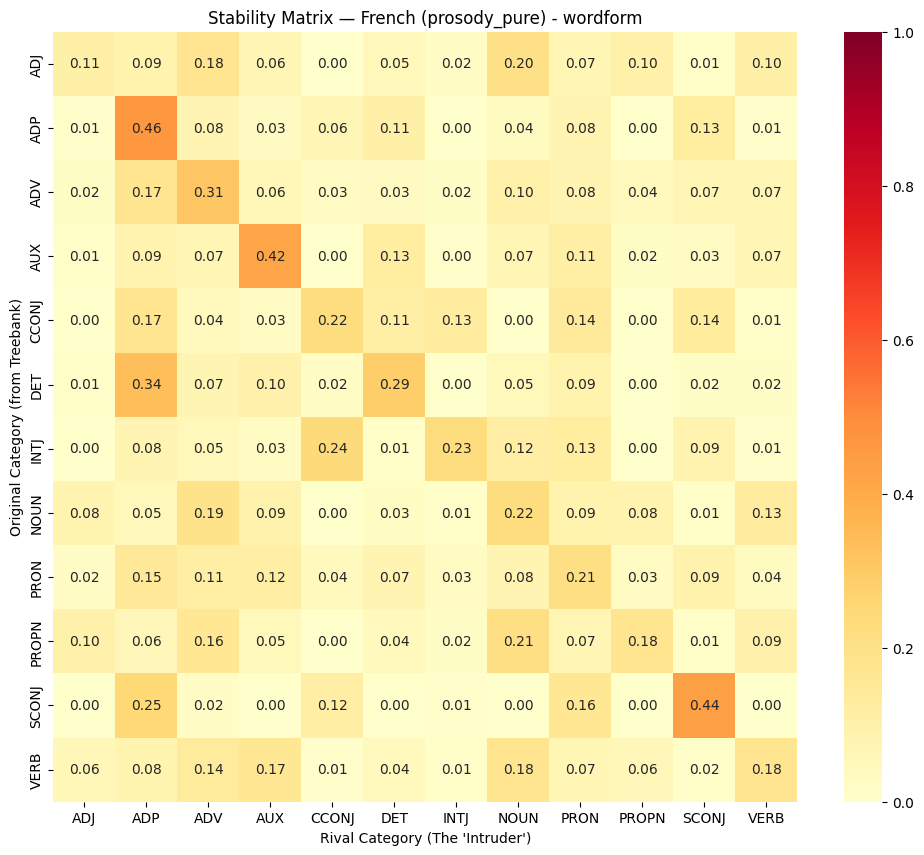

Neighbor,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,PRON,PROPN,SCONJ,VERB
Original,,,,,,,,,,,,
ADJ,0.107160,0.087927,0.177360,0.064445,0.002892,0.054005,0.021865,0.199351,0.068701,0.098551,0.014719,0.103024
ADP,0.005282,0.463224,0.076661,0.032654,0.064198,0.108494,0.000000,0.035402,0.078078,0.000687,0.127779,0.007541
ADV,0.018609,0.173005,0.308897,0.060053,0.028660,0.033214,0.017915,0.099519,0.077308,0.042847,0.066242,0.069902
AUX,0.008735,0.085340,0.067404,0.417901,0.000000,0.125174,0.004320,0.065377,0.113529,0.017265,0.029820,0.065135
CCONJ,0.000641,0.172760,0.043352,0.029006,0.223949,0.109770,0.131762,0.000773,0.143683,0.000000,0.135579,0.008726
DET,0.007997,0.335158,0.071833,0.096016,0.019711,0.287377,0.003299,0.049974,0.088389,0.002931,0.016214,0.018010
INTJ,0.001344,0.076407,0.051448,0.029765,0.241794,0.008056,0.227074,0.119464,0.128642,0.001900,0.085499,0.005003
NOUN,0.081993,0.051964,0.188970,0.090419,0.002184,0.026590,0.014301,0.224636,0.088878,0.082563,0.012806,0.131865
PRON,0.020087,0.149347,0.114669,0.119790,0.044752,0.074946,0.027577,0.077920,0.211587,0.027590,0.090747,0.037953


In [259]:
# Build a transition matrix for each feature space.
transition_matrices = {
    space: build_transition_matrix(sim, idx2lexunit, category_freqs)
    for space, sim in similarities.items()
}


# Show one — change SPACE to flip view.
SPACE = "prosody_pure"   # "syntactic", "prosodic_syntactic", "prosody_pure", "combined", "prosodic_foot", "prosodic_group", "prosodic_package", "prosodic_period", "prosodic_all_levels"
plot_transition_matrix(
    transition_matrices[SPACE],
    title=f"Stability Matrix — French ({SPACE}) - wordform",
    # drop_categories=("X", "SYM"),   # uncomment to hide noise categories
)
transition_matrices[SPACE]


In [120]:
print(transition_matrices[SPACE])

Neighbor       ADJ       ADP       ADV       AUX     CCONJ       DET  \
Original                                                               
ADJ       0.107549  0.089218  0.182972  0.063051  0.002773  0.053388   
ADP       0.005271  0.460963  0.074397  0.040191  0.063980  0.109283   
ADV       0.018562  0.174356  0.308408  0.058640  0.029994  0.034256   
AUX       0.010343  0.084244  0.059270  0.440803  0.000000  0.135999   
CCONJ     0.000313  0.178702  0.045638  0.028995  0.224595  0.103937   
DET       0.007850  0.338483  0.079869  0.097147  0.019720  0.283908   
INTJ      0.001345  0.076417  0.051219  0.029762  0.224119  0.009841   
NOUN      0.082284  0.052320  0.191672  0.090324  0.002451  0.025806   
PRON      0.020305  0.150305  0.116339  0.119509  0.047738  0.075152   
PROPN     0.098523  0.055241  0.159311  0.048164  0.003210  0.042750   
SCONJ     0.000000  0.246697  0.022111  0.000000  0.118540  0.003140   
VERB      0.060621  0.081467  0.142075  0.166891  0.008665  0.03

In [260]:
import itertools
import networkx as nx
 
FUNCTION_CATS = {"ADP", "AUX", "CCONJ", "DET", "PRON", "SCONJ", "PART"}
 
 
def evaluate_split(matrix, label="", function_cats=FUNCTION_CATS, verbose=True):
    """Score a stability matrix on how cleanly it separates function from content.
 
    The matrix is read as a weighted graph over categories and symmetrised
    (A~B strength = mean of A->B and B->A). Modularity Q measures how much
    weight stays inside the two groups rather than crossing between them.
 
    Because 12 categories give only 2047 possible two-way splits, we enumerate
    all of them. This gives an exact rank rather than a sampled p-value: rank 1
    means the function/content split is the single best partition of the
    category space that prosody could have found.
    """
    cats = [c for c in matrix.index if c in matrix.columns]
    M = matrix.loc[cats, cats]
    V = np.asarray(M.values, dtype=float)
    S = (V + V.T) / 2.0
 
    G = nx.from_pandas_adjacency(pd.DataFrame(S, index=cats, columns=cats))
    G.remove_edges_from(nx.selfloop_edges(G))
 
    def Q(group):
        group = set(group) & set(cats)
        other = set(cats) - group
        if not group or not other:
            return float("nan")
        return nx.community.modularity(G, [group, other], weight="weight")
 
    n = len(cats)
    all_splits = []
    for mask in range(1, 2 ** (n - 1)):
        grp = frozenset(cats[i] for i in range(n) if mask >> i & 1)
        if grp and set(grp) != set(cats):
            all_splits.append((Q(grp), grp))
    all_splits.sort(reverse=True)
 
    q_fc = Q(function_cats)
    rank = sum(1 for q, _ in all_splits if q > q_fc) + 1
    best_q, best_grp = all_splits[0]
    target = set(function_cats) & set(cats)
    recovers = set(best_grp) in (target, set(cats) - target)
 
    if verbose:
        print(f"--- {label} ---")
        print(f"  function/content   Q = {q_fc:.4f}   rank {rank} / {len(all_splits)}")
        print(f"  best split found   Q = {best_q:.4f}   {sorted(best_grp)}")
        print(f"  best split IS function/content: {recovers}")
        print(f"  mean self-stability (diagonal) = {np.mean(np.diag(V)):.4f}\n")
 
    return {
        "label": label,
        "Q_function_content": q_fc,
        "rank": rank,
        "n_partitions": len(all_splits),
        "Q_best": best_q,
        "best_group": sorted(best_grp),
        "recovers_split": recovers,
        "mean_diagonal": float(np.mean(np.diag(V))),
    }
 
 
# Sanity check: type- vs token-weighted, same feature space.
_sim = similarities["prosody_pure"]
results = [
    evaluate_split(
        build_transition_matrix(_sim, idx2lexunit, category_freqs_type),
        "prosody_pure / type-weighted (original)",
    ),
    evaluate_split(
        build_transition_matrix(_sim, idx2lexunit, category_freqs_token),
        "prosody_pure / token-weighted (corrected)",
    ),
]

--- prosody_pure / type-weighted (original) ---
  function/content   Q = 0.1302   rank 7 / 2047
  best split found   Q = 0.1854   ['ADP', 'CCONJ', 'DET', 'INTJ', 'PRON', 'SCONJ']
  best split IS function/content: False
  mean self-stability (diagonal) = 0.2720

--- prosody_pure / token-weighted (corrected) ---
  function/content   Q = 0.1330   rank 7 / 2047
  best split found   Q = 0.1761   ['ADP', 'CCONJ', 'DET', 'INTJ', 'PRON', 'SCONJ']
  best split IS function/content: False
  mean self-stability (diagonal) = 0.2632



In [261]:
import re
 
SYL_SLOT_RE = re.compile(r"childSyl(\d+):")
 
# Which columns belong to which syllable slot (childSylExt1 is deliberately
# not matched — the regex requires a digit straight after "childSyl").
syl_slot_cols = {}
for i, feat in idx2feature.items():
    m = SYL_SLOT_RE.search(feat)
    if m:
        syl_slot_cols.setdefault(int(m.group(1)), []).append(i)
 
# A unit "has" syllable k if any column in slot k is non-zero for it.
n_syl = np.ones(len(idx2lexunit), dtype=int)
for k in sorted(syl_slot_cols):
    present = (feature_matrix[:, syl_slot_cols[k]] > 0).any(axis=1)
    n_syl[present] = np.maximum(n_syl[present], k)
 
syl_df = pd.DataFrame({
    "lex_unit": [idx2lexunit[i] for i in range(len(idx2lexunit))],
    "POS":      [idx2lexunit[i][1] for i in range(len(idx2lexunit))],
    "n_syl":    n_syl,
    "n_occ":    n_occ,
})
syl_df["block"] = np.where(syl_df["POS"].isin(FUNCTION_CATS), "function", "content")
 
print("Syllable count by category (share of lexical unit TYPES):")
print(pd.crosstab(syl_df["POS"], syl_df["n_syl"], normalize="index").round(3), "\n")
 
print("Share of monosyllabic units, by block:")
print(syl_df.assign(mono=syl_df["n_syl"] == 1)
            .groupby("block")["mono"].agg(["mean", "size"]).round(3), "\n")
 
# How well does syllable count ALONE predict the block? This is the number a
# reviewer will want: it is the baseline your prosodic result has to beat.
mono_is_function = (syl_df["n_syl"] == 1) == (syl_df["block"] == "function")
print(f"Accuracy of the rule 'monosyllabic => function word': "
      f"{mono_is_function.mean():.3f} (types), "
      f"{np.average(mono_is_function, weights=syl_df['n_occ']):.3f} (tokens)")

Syllable count by category (share of lexical unit TYPES):
n_syl      1      2      3      4      5
POS                                     
ADJ    0.166  0.343  0.330  0.136  0.025
ADP    0.333  0.590  0.077  0.000  0.000
ADV    0.210  0.280  0.265  0.190  0.055
AUX    0.271  0.688  0.042  0.000  0.000
CCONJ  0.538  0.308  0.077  0.000  0.077
DET    0.409  0.477  0.091  0.023  0.000
INTJ   0.655  0.276  0.069  0.000  0.000
NOUN   0.193  0.426  0.251  0.097  0.034
NUM    1.000  0.000  0.000  0.000  0.000
PRON   0.565  0.398  0.037  0.000  0.000
PROPN  0.204  0.427  0.296  0.060  0.012
SCONJ  0.692  0.308  0.000  0.000  0.000
VERB   0.163  0.474  0.308  0.055  0.001
X      1.000  0.000  0.000  0.000  0.000 

Share of monosyllabic units, by block:
           mean  size
block                
content   0.189  4571
function  0.450   309 

Accuracy of the rule 'monosyllabic => function word': 0.789 (types), 0.612 (tokens)


In [262]:
# The two independent controls.
#   1. length-blind : drop the childSyl2..N columns, keep every word.
#   2. monosyllabic : keep every column, keep only 1-syllable words.
# If the function/content split survives both, syllable count was not driving it.
# =============================================================================
 
def _slot_number(feat):
    m = SYL_SLOT_RE.search(feat)
    return int(m.group(1)) if m else None
 
 
# --- control 1: length-blind feature space --------------------------------
# Columns for syllables 2+ are non-zero only for longer words, so their zero
# pattern encodes word length. Removing them makes every word look the same
# length to cosine similarity.
length_revealing = np.array([
    (_slot_number(f) or 0) >= 2 for f in idx2feature.values()
])
length_blind_mask = prosody_pure_mask & ~length_revealing
 
print(f"prosody_pure columns:        {int(prosody_pure_mask.sum())}")
print(f"length-blind columns:        {int(length_blind_mask.sum())} "
      f"(dropped {int((prosody_pure_mask & length_revealing).sum())})\n")
 
similarities["prosody_length_blind"] = cosine_similarity(
    feature_matrix[:, length_blind_mask])
SPACE_MASKS["prosody_length_blind"] = length_blind_mask
 
results.append(evaluate_split(
    build_transition_matrix(similarities["prosody_length_blind"],
                            idx2lexunit, category_freqs_token),
    "control 1: length-blind columns, all words",
))
 
 
# --- control 2: monosyllabic words only ------------------------------------
def restricted_matrix(row_mask, space="prosody_pure", weight_by="token"):
    """Rebuild a stability matrix over a subset of lexical units.
 
    Category frequencies are recomputed inside the subset, so the P_norm
    denominator stays correct for the restricted population.
    """
    keep = np.where(row_mask)[0]
    sub_idx2lexunit = {new: idx2lexunit[old] for new, old in enumerate(keep)}
    sub_n_occ = n_occ[keep]
 
    col_mask = SPACE_MASKS[space]
    X = feature_matrix if col_mask is None else feature_matrix[:, col_mask]
    sub_sim = cosine_similarity(X[keep])
 
    sub_freqs = make_category_freqs(sub_idx2lexunit, sub_n_occ, weight_by=weight_by)
    return build_transition_matrix(sub_sim, sub_idx2lexunit, sub_freqs)
 
 
mono_mask = n_syl == 1
print(f"monosyllabic lexical units: {int(mono_mask.sum())} / {len(n_syl)}")
print("categories surviving in the monosyllabic subset:")
print(syl_df.loc[mono_mask, "POS"].value_counts().to_string(), "\n")
 
results.append(evaluate_split(
    restricted_matrix(mono_mask, space="prosody_pure"),
    "control 2: all columns, monosyllabic words only",
))
 
# Optional third row: both controls at once, the strictest test.
results.append(evaluate_split(
    restricted_matrix(mono_mask, space="prosody_length_blind"),
    "controls 1+2 combined",
))
 
 
# --- summary table for the paper -------------------------------------------
summary = pd.DataFrame(results)[
    ["label", "mean_diagonal", "Q_function_content", "rank",
     "n_partitions", "Q_best", "recovers_split"]
]
print("\n", summary.to_string(index=False))

prosody_pure columns:        599
length-blind columns:        540 (dropped 59)

--- control 1: length-blind columns, all words ---
  function/content   Q = 0.1520   rank 5 / 2047
  best split found   Q = 0.1635   ['ADP', 'CCONJ', 'DET', 'INTJ', 'PRON', 'SCONJ']
  best split IS function/content: False
  mean self-stability (diagonal) = 0.2560

monosyllabic lexical units: 1001 / 4880
categories surviving in the monosyllabic subset:
POS
NOUN     351
VERB     225
ADJ      106
PROPN     98
PRON      61
ADV       42
DET       36
X         20
INTJ      19
AUX       13
ADP       13
SCONJ      9
CCONJ      7
NUM        1 

--- control 2: all columns, monosyllabic words only ---
  function/content   Q = 0.0832   rank 16 / 2047
  best split found   Q = 0.1258   ['ADP', 'ADV', 'CCONJ', 'INTJ', 'PRON', 'SCONJ']
  best split IS function/content: False
  mean self-stability (diagonal) = 0.1712

--- controls 1+2 combined ---
  function/content   Q = 0.0832   rank 16 / 2047
  best split found   Q = 0.1

In [121]:
def get_top_bridge_words(scores_dict, original_cat, rival_cat, top_n=100):
    """Words from `original_cat` most pulled toward `rival_cat`."""
    matches = [
        {"word": word, "purity": float(d["purity"]), "entropy": float(d["entropy"])}
        for (word, o_cat), d in scores_dict.items()
        if o_cat == original_cat and d["rival_category"] == rival_cat
    ]
    # Lowest combined score first — least pure, highest entropy.
    # matches.sort(key=lambda x: 0.7 * x["purity"] - 0.3 * x["entropy"])
    matches.sort(key=lambda x: x["purity"])
    return [(m["word"], f'{m["purity"]:.2f}', f'{m["entropy"]:.2f}')
            for m in matches[:top_n]]


In [122]:
# ── Pick a feature space and a category pair ──────────────────────────────
SPACE          = "prosody_pure"        # "syntactic" | "prosodic_syntactic" | "prosody_pure" | "combined"
ORIGINAL_CAT   = "VERB"
RIVAL_CAT      = "AUX"

scores = scores_by_space[SPACE]
bridge_words = get_top_bridge_words(scores, ORIGINAL_CAT, RIVAL_CAT)

print(f"Top {ORIGINAL_CAT} → {RIVAL_CAT} bridge words ({SPACE} space):")
print(f"{'Word':<20} {'Purity':>8} {'Entropy':>8}")
for word, purity, ent in bridge_words:
    print(f"{word:<20} {purity:>8} {ent:>8}")


Top VERB → AUX bridge words (prosody_pure space):
Word                   Purity  Entropy
annoncera                0.00     0.78
assure                   0.00     0.49
reviens                  0.00     0.00
travaillé                0.00     1.27
va                       0.00     1.45
ont                      0.00     1.28
pourrait                 0.00     1.24
lu                       0.01     1.37
peut                     0.01     1.41
faut                     0.01     1.45
retrouve                 0.01     1.32
doit                     0.01     1.42
veux                     0.01     1.51
comprend                 0.01     1.33
vas                      0.01     0.82
restent                  0.01     1.40
arrivé                   0.01     1.05
veut                     0.01     1.26
semblait                 0.01     1.63
sais                     0.01     1.03
remettre                 0.01     1.41
appelait                 0.01     0.83
a                        0.01     1.44
avoir         

In [164]:
bridge_words

[('annoncera', '0.00', '0.78'),
 ('assure', '0.00', '0.49'),
 ('reviens', '0.00', '0.00'),
 ('travaillé', '0.00', '1.27'),
 ('va', '0.00', '1.45'),
 ('ont', '0.00', '1.28'),
 ('pourrait', '0.00', '1.24'),
 ('lu', '0.01', '1.37'),
 ('peut', '0.01', '1.41'),
 ('faut', '0.01', '1.45'),
 ('retrouve', '0.01', '1.32'),
 ('doit', '0.01', '1.42'),
 ('veux', '0.01', '1.51'),
 ('comprend', '0.01', '1.33'),
 ('vas', '0.01', '0.82'),
 ('restent', '0.01', '1.40'),
 ('arrivé', '0.01', '1.05'),
 ('veut', '0.01', '1.26'),
 ('semblait', '0.01', '1.63'),
 ('sais', '0.01', '1.03'),
 ('remettre', '0.01', '1.41'),
 ('appelait', '0.01', '0.83'),
 ('a', '0.01', '1.44'),
 ('avoir', '0.01', '1.02'),
 ('ai', '0.01', '1.10'),
 ('être', '0.02', '0.86'),
 ('parler', '0.02', '1.05'),
 ('eu', '0.02', '1.41'),
 ('allez', '0.02', '0.79'),
 ('avaient', '0.02', '0.82'),
 ('entendre', '0.02', '1.19'),
 ('allait', '0.02', '1.43'),
 ('entend', '0.02', '1.53'),
 ('tourniez', '0.02', '0.16'),
 ('a~', '0.02', '0.72'),
 ('rest

In [123]:
def get_pulling_features(
    lex_unit, rival_category,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    """Features pulling `lex_unit` toward `rival_category`.

    Score = (unit's coverage on the feature) / (|unit_value − rival_centroid| + ε).
    Features the unit doesn't use at all (zero coverage) score zero — they
    can't be pulling anything.
    """
    unit_idx = lexunit2idx[lex_unit]
    unit_vector = feature_matrix[unit_idx]

    # Top-k neighbours.
    candidate_idx = np.where(similarity_matrix[unit_idx] >= sim_threshold)[0]
    neighbour_indices = sorted(
        [i for i in candidate_idx if i != unit_idx],
        key=lambda i: similarity_matrix[unit_idx][i],
        reverse=True,
    )[:max_neighbours]

    # Rival centroid: median over rival-category neighbours.
    rival_neighbour_indices = [
        i for i in neighbour_indices if idx2lexunit[i][1] == rival_category
    ]
    if not rival_neighbour_indices:
        print(f"No neighbours of category '{rival_category}' found for {lex_unit}.")
        return []
    rival_centroid = np.median(feature_matrix[rival_neighbour_indices], axis=0)

    feature_differences = np.abs(unit_vector - rival_centroid)
    eps = 1e-6
    scores = np.where(
        unit_vector > 0,
        unit_vector / (feature_differences + eps),
        0.0,
    )

    # Restrict scoring to the active feature space. Without this, neighbours
    # are chosen by (e.g.) syntactic similarity but the top-ranked pulling
    # features can come from any column of the full matrix.
    if feature_mask is not None:
        scores = np.where(feature_mask, scores, 0.0)

    top_idx = np.argsort(scores)[::-1][:top_k_features]
    return [
        {
            "feature":    idx2feature[f_idx],
            "unit_value": unit_vector[f_idx],
            "rival_avg":  rival_centroid[f_idx],
            "diff":       feature_differences[f_idx],
            "score":      scores[f_idx],
        }
        for f_idx in top_idx
        if scores[f_idx] > 0
    ]


In [240]:
def get_pulling_features_by_mass(
    lex_unit, rival_category,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    """Features that actually build the unit↔rival cosine similarity.
 
    Restrict to the active space, L2-normalise the unit (û) and each rival
    neighbour, average the normalised rivals into a direction r̂, then rank
    features by ûᵢ · r̂ᵢ. These contributions sum to the mean cosine similarity
    between the unit and its rival-category neighbours, so `share` tells you how
    much of the overlap each feature is responsible for.
    """
    unit_idx = lexunit2idx[lex_unit]
 
    cols = np.where(feature_mask)[0] if feature_mask is not None \
        else np.arange(feature_matrix.shape[1])
 
    u = feature_matrix[unit_idx, cols].astype(float)
    u_norm = np.linalg.norm(u)
    if u_norm == 0:
        return []
    u_hat = u / u_norm
 
    candidate_idx = np.where(similarity_matrix[unit_idx] >= sim_threshold)[0]
    neighbour_indices = sorted(
        [i for i in candidate_idx if i != unit_idx],
        key=lambda i: similarity_matrix[unit_idx][i], reverse=True,
    )[:max_neighbours]
    rival_neighbour_indices = [
        i for i in neighbour_indices if idx2lexunit[i][1] == rival_category
    ]
    if not rival_neighbour_indices:
        print(f"No neighbours of category '{rival_category}' found for {lex_unit}.")
        return []
 
    rival_block = feature_matrix[np.ix_(rival_neighbour_indices, cols)].astype(float)
    rn = np.linalg.norm(rival_block, axis=1, keepdims=True)
    rn[rn == 0] = 1.0
    rival_hat = (rival_block / rn).mean(axis=0)
 
    contribution = u_hat * rival_hat          # sums to mean cosine similarity
    total = contribution.sum()
 
    order = np.argsort(contribution)[::-1][:top_k_features]
    rows = []
    for local_i in order:
        c = contribution[local_i]
        if c <= 0:
            continue
        g_idx = int(cols[local_i])
        rows.append({
            "feature":      idx2feature[g_idx],
            "unit_value":   float(u[local_i]),
            "rival_dir":    float(rival_hat[local_i]),
            "contribution": float(c),
            "share":        float(c / total) if total > 0 else 0.0,
        })
    return rows

In [241]:
SPACE     = "prosody_pure"
LEX_UNIT  = ('dois', 'VERB')
RIVAL_CAT = "AUX"
 
results = get_pulling_features_by_mass(
    LEX_UNIT, RIVAL_CAT,
    feature_matrix, similarities[SPACE],
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_features=20,
)
 
print(f"Top features building the {LEX_UNIT} → {RIVAL_CAT} similarity "
      f"({SPACE} space):")
print(f"{'Feature':<48} {'unit':>6}  {'r_dir':>6}  {'contrib':>8}  {'share':>6}")
print("-" * 82)
for r in results:
    print(f"{r['feature']:<48} {r['unit_value']:>6.3f}  {r['rival_dir']:>6.3f}  "
          f"{r['contribution']:>8.4f}  {r['share']:>5.1%}")

Top features building the ('dois', 'VERB') → AUX similarity (prosody_pure space):
Feature                                            unit   r_dir   contrib   share
----------------------------------------------------------------------------------
node:X:own:Package=In                             1.000   0.144    0.0206   2.9%
node:X:prevSyl:AvgHeightGlo=M                     1.000   0.130    0.0186   2.6%
node:X:prevSyl:PitchRangeGlo=L                    1.000   0.125    0.0179   2.5%
node:X:childSyl1:PitchRangeGlo=L                  0.667   0.146    0.0140   2.0%
node:X:childSyl1:AvgHeightGlo=M                   0.667   0.144    0.0137   1.9%
node:X:prev:Package=In                            1.000   0.095    0.0136   1.9%
node:X:childSyl1:SlopeGlo=Flat                    0.667   0.133    0.0127   1.8%
node:X:next:RhythmGroup=Strong                    1.000   0.087    0.0124   1.7%
node:X:prev:Group=In                              1.000   0.079    0.0113   1.6%
node:X:prev:Foot=In     

In [126]:
def get_aggregate_pulling_features(
    scores_dict, original_cat, rival_cat,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_words=10, top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    """Cross-word aggregate of the pulling features for an `original_cat`
    → `rival_cat` direction.

    A feature appears in the aggregate if it surfaced for at least one bridge
    word. Ranked by how many bridge words it shows up in (robustness), with
    average unit value as a tiebreaker.
    """
    bridge_words = get_top_bridge_words(scores_dict, original_cat, rival_cat,
                                        top_n=top_k_words)
    if not bridge_words:
        print(f"No bridge words found from {original_cat} to {rival_cat}")
        return None

    print(f"Analyzing {len(bridge_words)} bridge words: "
          f"{[w[0] for w in bridge_words]}\n")

    per_feature = {}
    for word, _purity, _entropy in bridge_words:
        lex_unit = (word, original_cat)
        if lex_unit not in lexunit2idx:
            print(f"  WARNING: {lex_unit} not found in lexunit2idx, skipping.")
            continue

        word_features = get_pulling_features(
            lex_unit=lex_unit, rival_category=rival_cat,
            feature_matrix=feature_matrix, similarity_matrix=similarity_matrix,
            idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
            idx2feature=idx2feature, feature2idx=feature2idx,
            feature_mask=feature_mask,
            top_k_features=top_k_features * 2,   # cast wide before aggregating
            sim_threshold=sim_threshold, max_neighbours=max_neighbours,
        )
        for fd in word_features:
            d = per_feature.setdefault(fd["feature"],
                                       {"unit_values": [], "rival_avgs": [], "diffs": []})
            d["unit_values"].append(fd["unit_value"])
            d["rival_avgs"].append(fd["rival_avg"])
            d["diffs"].append(fd["diff"])

    if not per_feature:
        print("No features collected — check bridge words and similarity threshold.")
        return None

    rows = [
        {
            "feature":         fname,
            "count_words":     len(d["unit_values"]),
            "avg_unit_value":  float(np.mean(d["unit_values"])),
            "avg_rival_value": float(np.mean(d["rival_avgs"])),
            "avg_diff":        float(np.mean(d["diffs"])),
            "std_unit_value":  float(np.std(d["unit_values"])),
        }
        for fname, d in per_feature.items()
    ]
    rows.sort(key=lambda r: (r["count_words"], r["avg_unit_value"]), reverse=True)
    return pd.DataFrame(rows[:top_k_features])


In [242]:
def get_aggregate_pulling_features_by_mass(
    scores_dict, original_cat, rival_cat,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_words=10, top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    bridge_words = get_top_bridge_words(scores_dict, original_cat, rival_cat,
                                        top_n=top_k_words)
    if not bridge_words:
        print(f"No bridge words found from {original_cat} to {rival_cat}")
        return None
 
    print(f"Analyzing {len(bridge_words)} bridge words: "
          f"{[w[0] for w in bridge_words]}\\n")
 
    per_feature = {}
    for word, _p, _e in bridge_words:
        lex_unit = (word, original_cat)
        if lex_unit not in lexunit2idx:
            continue
        feats = get_pulling_features_by_mass(
            lex_unit=lex_unit, rival_category=rival_cat,
            feature_matrix=feature_matrix, similarity_matrix=similarity_matrix,
            idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
            idx2feature=idx2feature, feature2idx=feature2idx,
            feature_mask=feature_mask,
            top_k_features=top_k_features * 3,
            sim_threshold=sim_threshold, max_neighbours=max_neighbours,
        )
        for fd in feats:
            d = per_feature.setdefault(
                fd["feature"],
                {"contribs": [], "unit_values": []},
            )
            d["contribs"].append(fd["contribution"])
            d["unit_values"].append(fd["unit_value"])
 
    if not per_feature:
        print("No features collected — check bridge words and similarity threshold.")
        return None
 
    rows = [{
        "feature":        fname,
        "count_words":    len(d["contribs"]),
        "total_contrib":  float(np.sum(d["contribs"])),
        "avg_contrib":    float(np.mean(d["contribs"])),
        "avg_unit_value": float(np.mean(d["unit_values"])),
    } for fname, d in per_feature.items()]
    rows.sort(key=lambda r: r["total_contrib"], reverse=True)
    return pd.DataFrame(rows[:top_k_features])

In [243]:
SPACE        = "prosody_pure"
ORIGINAL_CAT = "ADJ"
RIVAL_CAT    = "NOUN"
 
df_mass = get_aggregate_pulling_features_by_mass(
    scores_dict=scores_by_space[SPACE],
    original_cat=ORIGINAL_CAT, rival_cat=RIVAL_CAT,
    feature_matrix=feature_matrix,
    similarity_matrix=similarities[SPACE],
    idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
    idx2feature=idx2feature, feature2idx=feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_words=40, top_k_features=25,
)
 
if df_mass is not None:
    print(df_mass.to_string(index=False))

Analyzing 40 bridge words: ['Haut', 'abominable', 'accueillant', 'africaines', 'amical', 'autrichien', 'bourgeoise', 'bénéfique', 'chrétiens', 'civiles', 'commun', 'complexes', 'cumulatif', 'différent', 'direct', 'forts', 'haute', 'historiques', 'honteux', 'lumineuse', 'meilleures', 'médiane', 'médico-sociales', 'nouvel', 'onéreux', 'orthodoxe', 'pareilles', 'plein', 'relatif', 'sincère', 'spécialisé', 'stratifiée', 'vain', 'vide', 'étonnée', 'doué', 'libre', 'actuelle', 'élégante', 'concrets']\n
                          feature  count_words  total_contrib  avg_contrib  avg_unit_value
 node:X:childSyl1:PitchRangeGlo=L           33       0.410830     0.012449        0.969697
    node:X:prevSyl:AvgHeightGlo=M           30       0.380385     0.012680        0.950000
   node:X:prevSyl:PitchRangeGlo=L           30       0.377972     0.012599        0.966667
node:X:own:ProminenceFinal=Strong           30       0.354994     0.011833        0.950000
    node:X:own:RhythmGroup=Strong          

Bridge words: ['reviens', 'tourniez', 'suffit', 'reçois', 'savons', 'voyaient', 'unit', 'interprété', 'savait', 'commence', 'voudrais', 'proposons', 'assure', 'sent', 'devenir', 'chasser', 'allez', 'avez', 'tombez', 'échanger', 'étaient', 'a~', 'verra', 'parlaient', 'fallu', 'volé', 'avancer', 'serez', 'appelait', 'irai', 'connu', 'gagner', 'obtenu', 'aura', 'venaient', 'avaient', 'connaissons', 'gagnais', 'voulais', 'choquée', 'corromp~', 'pouvez', 'passée', 'attendu', 'avais', 'étions', 'devait', 'être', 'aider', 'restée', 'revenue', 'vécu', 'partie', 'augmenté', 'lit', 'disais', 'voulaient', 'font', 'dû', 'changer', 'faisais', 'suivez', 'dessinent', 'paraissaient', 'habiller', 'demandé', 'commencé', 'connaissais', 'découvrir', 'continues', 'réussir', 'faisait', 'attend', 'redis', 'pourraient', 'tombent', 'baladant', 'passes', 'émanait']
bridge VERB: median 3 occ, 66% occur 3x or fewer (n=79)
other  VERB: median 1 occ, 86% occur 3x or fewer (n=1303)
    variable  value  p_orig  p_bri

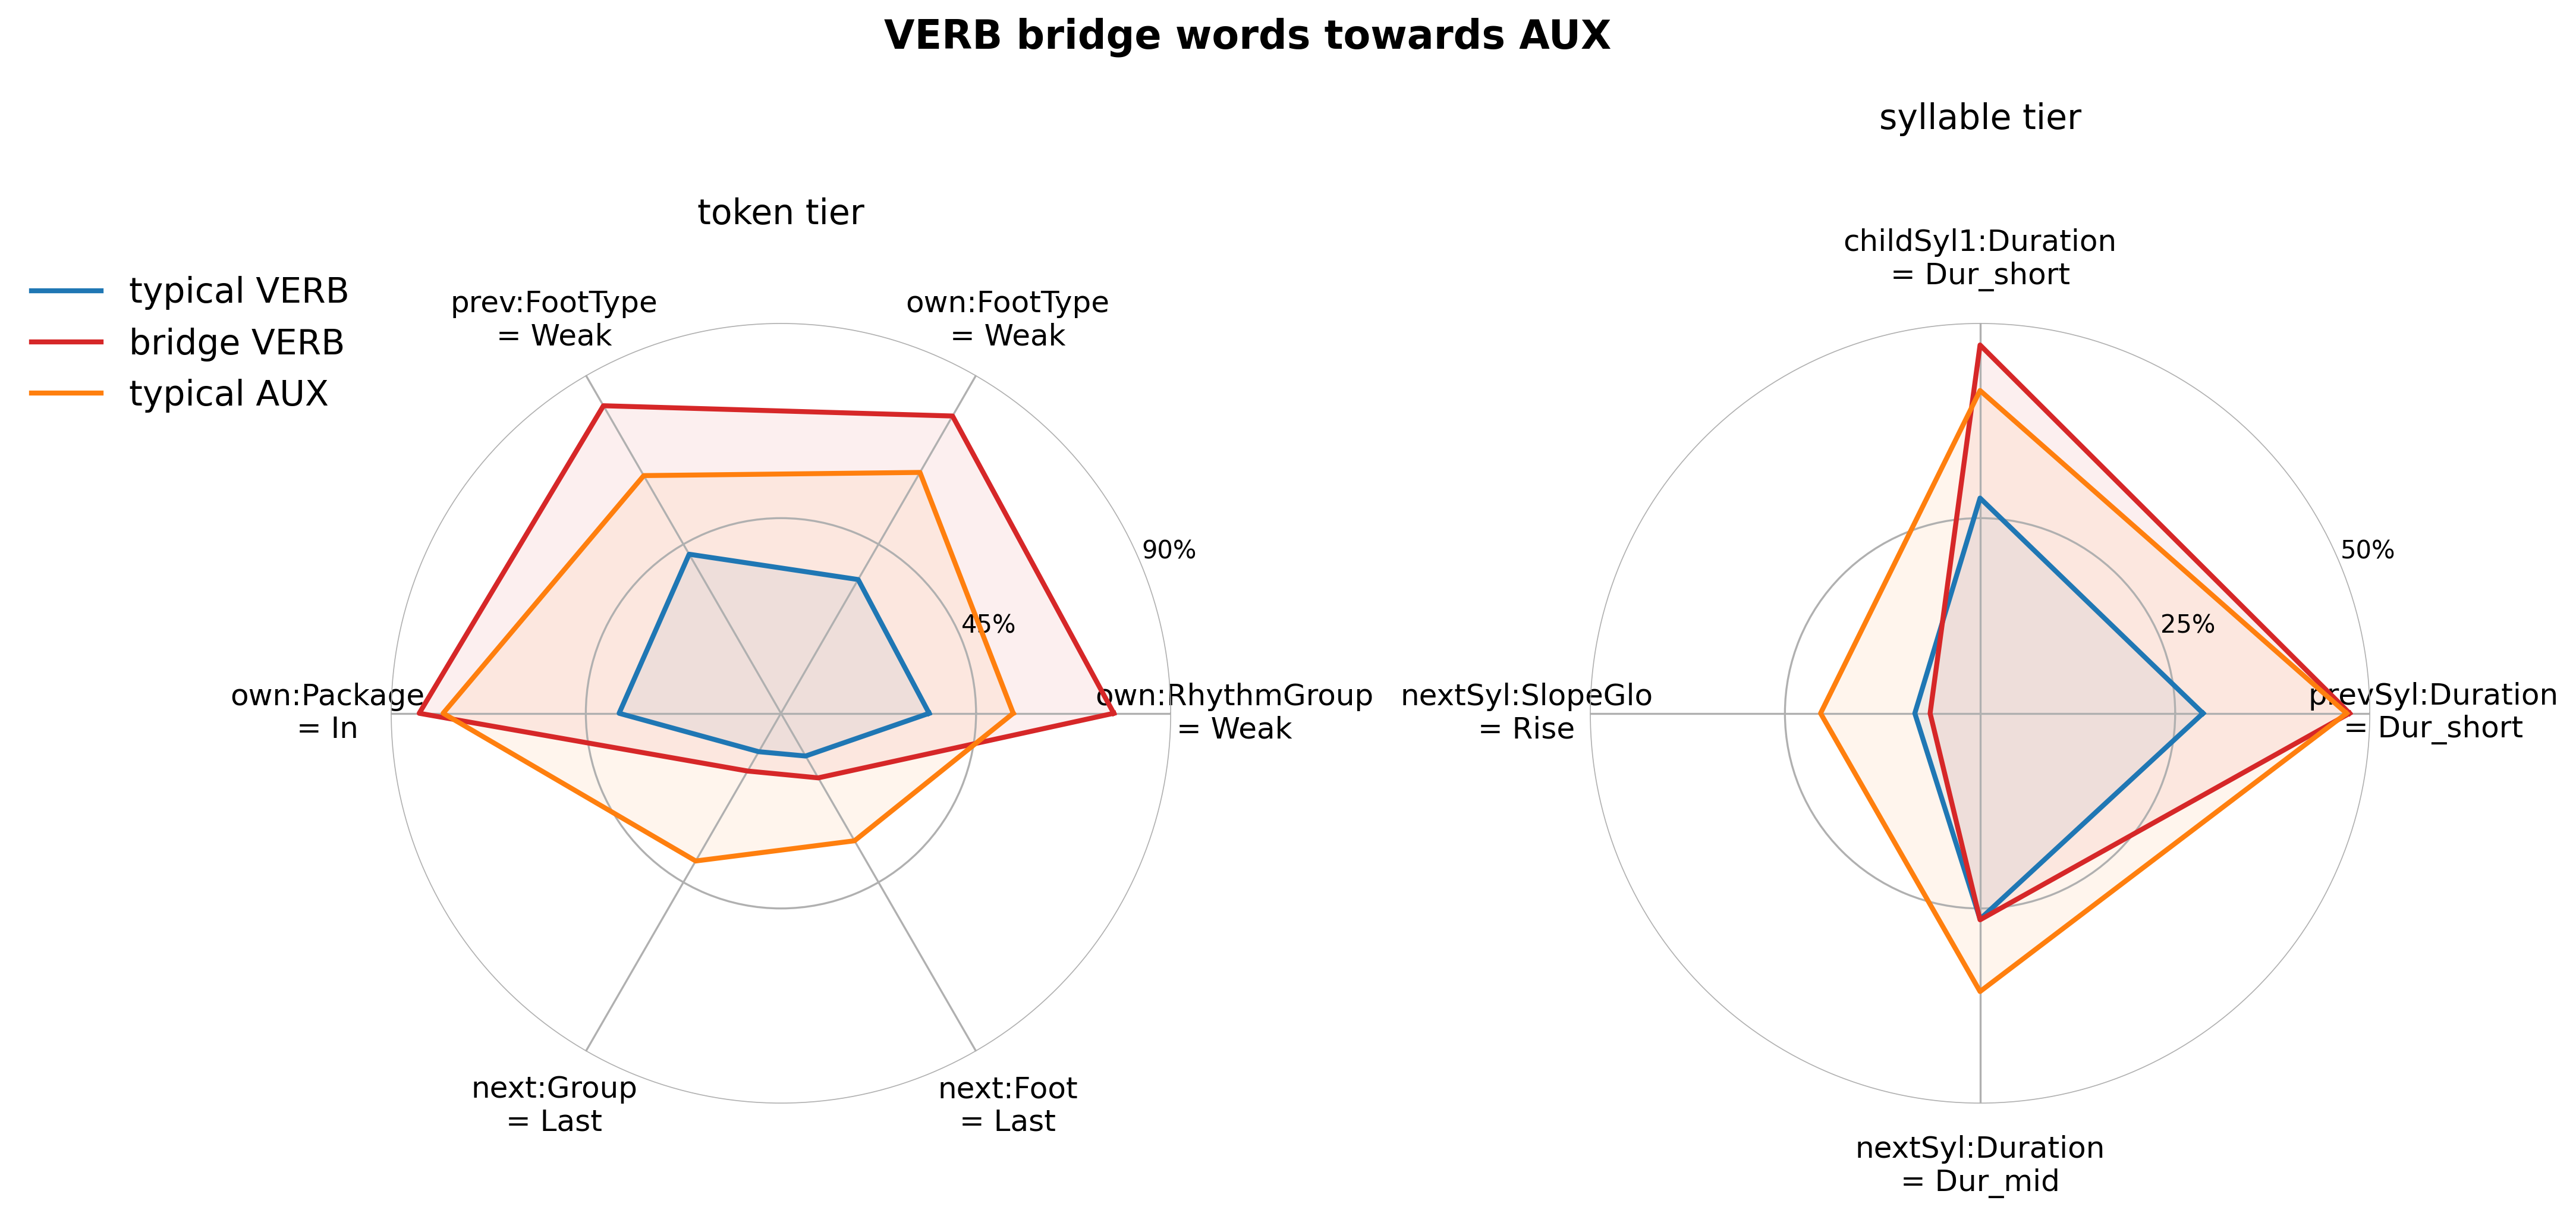

In [319]:
# =============================================================================
# Replaces get_aggregate_pulling_features_by_mass for interpretation purposes.
#
# The old function asks "why is this word similar to auxiliaries?" and answers
# with features that are near-universal in the corpus. This asks "how does this
# word differ from a typical verb, and does that difference point at AUX?"
#
# One row per (variable, value). One axis per VARIABLE, never per feature --
# Group=Begin/In/Last/Unique are alternatives, so averaging them cancels out.
# =============================================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SLOT_RE = re.compile(r"^node:X:([^:]+):")
def bridge_table(scores, original_cat, rival_cat):
    """All candidates, with the quantities that actually define a bridge."""
    rows = []
    for (word, cat), d in scores.items():
        if cat != original_cat or d["rival_category"] != rival_cat:
            continue
        p, r = float(d["purity"]), float(d["rival_weight_ratio"])
        rows.append({"word": word, "purity": p, "rival_share": r,
                     "entropy": float(d["entropy"]),
                     "concentration": p + r,     # mass in just these two categories
                     "bridge_score": r - p})     # >0 = more rival-like than own-like
    return pd.DataFrame(rows).sort_values("bridge_score", ascending=False)


# for orig, riv in [("VERB","AUX"), ("ADJ","NOUN"), ("ADJ","ADV"),
#                   ("DET","ADP"), ("ADV","ADP"), ("PROPN","NOUN")]:
#     t = bridge_table(scores_by_space["prosody_pure"], orig, riv)
#     print(f"{orig:6s}->{riv:6s}  candidates={len(t):4d}  "
#           f"score>0: {(t['bridge_score']>0).sum():4d}  "
#           f"concentration>=0.8: {(t['concentration']>=0.8).sum():4d}")
def select_bridge_words(scores, original_cat, rival_cat,
                        min_bridge_score=0.0, min_concentration=0.7, max_n=None):
    t = bridge_table(scores, original_cat, rival_cat)
    t = t[(t["bridge_score"] >= min_bridge_score) &
          (t["concentration"] >= min_concentration)]
    if max_n:
        t = t.head(max_n)
    return t["word"].tolist()

def build_profile(original_cat, rival_cat, space="prosody_pure", n_bridge=40):
    """Three group means for every feature, tidied into variable/value rows.

    typical original : mean over ALL units of original_cat, bridge words removed
    bridge           : mean over the bridge words
    typical rival    : mean over ALL units of rival_cat

    'gap'      = how far apart the two categories are on this feature
    'position' = where the bridge words sit, 0 = at original, 1 = at rival
    """
    bridge_words = select_bridge_words(scores_by_space[space], original_cat, rival_cat)
    
    print(f"Bridge words: {bridge_words}")
    bw = set(bridge_words)
    occ_all = {w: n_occ[lexunit2idx[(w, original_cat)]]
               for (w, c) in idx2lexunit.values() if c == original_cat
               and (w, original_cat) in lexunit2idx}
    b = np.array([v for w, v in occ_all.items() if w in bw])
    a = np.array([v for w, v in occ_all.items() if w not in bw])
    print(f"bridge {original_cat}: median {np.median(b):.0f} occ, "
          f"{np.mean(b <= 3):.0%} occur 3x or fewer (n={len(b)})")
    print(f"other  {original_cat}: median {np.median(a):.0f} occ, "
          f"{np.mean(a <= 3):.0%} occur 3x or fewer (n={len(a)})")
    
    bridge_ids = np.array([lexunit2idx[(w, original_cat)] for w in bridge_words
                           if (w, original_cat) in lexunit2idx], dtype=int)
    excl = set(bridge_ids.tolist())
    orig_ids = np.array([i for i, lu in idx2lexunit.items()
                         if lu[1] == original_cat and i not in excl], dtype=int)
    rival_ids = np.array([i for i, lu in idx2lexunit.items()
                          if lu[1] == rival_cat], dtype=int)

    mask = SPACE_MASKS[space]
    cols = (np.arange(feature_matrix.shape[1]) if mask is None
            else np.where(mask)[0])
    names = [idx2feature[c] for c in cols]
    X = feature_matrix[:, cols]

    p_orig, p_brid, p_riv = (X[orig_ids].mean(0), X[bridge_ids].mean(0),
                             X[rival_ids].mean(0))

    rows = []
    for j, f in enumerate(names):
        if "=" not in f:
            continue
        var, value = f.rsplit("=", 1)
        slot = SLOT_RE.match(f).group(1)
        rows.append({"variable": var.replace("node:X:", ""), "value": value,
                     "slot": slot, "tier": "syllable" if "Syl" in slot else "token",
                     "p_orig": p_orig[j], "p_bridge": p_brid[j], "p_rival": p_riv[j]})

    df = pd.DataFrame(rows)
    df["gap"] = df["p_rival"] - df["p_orig"]
    with np.errstate(divide="ignore", invalid="ignore"):
        df["position"] = np.where(np.abs(df["gap"]) > 1e-9,
                                  (df["p_bridge"] - df["p_orig"]) / df["gap"], np.nan)
    df.attrs["cats"] = (original_cat, rival_cat)
    df.attrs["n"] = dict(zip(["orig", "bridge", "rival"],
                             [len(orig_ids), len(bridge_ids), len(rival_ids)]))
    df.attrs["bridge_words"] = bridge_words
    return df


def pick_axes(df, tier=None, n_axes=8, min_gap=0.08):
    """One axis per variable: the value that best separates the two categories,
    oriented so the rival category always sits further out. 'Further from the
    centre' therefore reads as 'more rival-like' on every axis."""
    d = df if tier is None else df[df["tier"] == tier]
    d = d[d["gap"] > min_gap]
    best = (d.sort_values("gap", ascending=False)
              .drop_duplicates("variable")
              .head(n_axes).copy())
    best["label"] = best["variable"] + " = " + best["value"]
    return best.sort_values("gap", ascending=False).reset_index(drop=True)

def axes_from_labels(df, labels):
    """Build the axis frame from an explicit list of 'variable = value' strings,
    in the order given. Bypasses the automatic gap-based selection."""
    d = df.copy()
    d["label"] = d["variable"] + " = " + d["value"]
    missing = [l for l in labels if l not in set(d["label"])]
    if missing:
        raise ValueError(f"not found in df: {missing}")
    return (d[d["label"].isin(labels)]
              .set_index("label").loc[labels].reset_index())


# --- figure 1: two radars, one per annotation tier ---------------------------

def plot_radars(df, n_axes=7, min_gap=0.08, manual=None):
    o, r = df.attrs["cats"]
    series = [(f"typical {o}", "p_orig", "tab:blue"),
              (f"bridge {o}", "p_bridge", "tab:red"),
              (f"typical {r}", "p_rival", "tab:orange")]
    
    if manual:
        tiers = list(manual)
    else:
        tiers = [t for t in ["token", "syllable"]
                 if len(pick_axes(df, t, n_axes, min_gap)) >= 3]
                 
    fig, axs = plt.subplots(1, len(tiers), figsize=(7.5 * len(tiers), 7),
                            subplot_kw=dict(polar=True), dpi=300)
    axs = np.atleast_1d(axs)
    
    for ax, tier in zip(axs, tiers):
        a = axes_from_labels(df, manual[tier]) if manual \
            else pick_axes(df, tier, n_axes, min_gap)
        
        ang = np.linspace(0, 2 * np.pi, len(a), endpoint=False).tolist()
        ang += ang[:1]
        
        for name, col, c in series:
            v = a[col].tolist()
            v += v[:1]
            ax.plot(ang, v, color=c, linewidth=2, label=name)
            ax.fill(ang, v, color=c, alpha=0.07)
            
        top = float(np.ceil(a[["p_orig", "p_bridge", "p_rival"]].values.max() * 10) / 10)
        ax.set_ylim(0, top)
        
        ticks = np.linspace(0, top, 3)[1:]
        ax.set_yticks(ticks)
        
        # INCREASED FONT SIZE for the inner circle numbers (from 7 to 10)
        ax.set_yticklabels([f"{t:.0%}" for t in ticks], fontsize=10)
        
        formatted_labels = [label.replace(" = ", "\n= ") for label in a["label"]]
        
        ax.set_xticks(ang[:-1])
        ax.set_xticklabels(formatted_labels, fontsize=12, ha="center")
        
        ax.tick_params(axis='x', pad=15)
        ax.spines['polar'].set_visible(False)
        
        # INCREASED PAD to push the subtitle away from the plot (from 26 to 40)
        ax.set_title(f"{tier} tier", pad=40, fontsize=14)
        
    axs[0].legend(loc="upper left", bbox_to_anchor=(-0.5, 1.1), frameon=False, fontsize=14)
    
    fig.suptitle(f"{o} bridge words towards {r}", fontsize=16, fontweight="bold")
    
    # ADJUSTED RECT to bring the main title slightly down and frame everything nicely
    fig.tight_layout(rect=[0, 0, 1, 1])
    
    return fig


# --- figure 2: where the bridge words sit, one dot per variable ---------------

def plot_positions(df, n_axes=14, min_gap=0.08):
    """The summary figure: for each variable, how far the bridge words have
    travelled from the original category toward the rival."""
    o, r = df.attrs["cats"]
    a = pick_axes(df, None, n_axes, min_gap).iloc[::-1]
    y = np.arange(len(a))

    fig, ax = plt.subplots(figsize=(9, 0.3 * len(a) + 2))
    ax.hlines(y, 0, 1, color="0.85", lw=1, zorder=0)
    ax.scatter(a["position"].clip(-0.15, 1.15), y,
               s=90, c=np.where(a["tier"] == "token", "tab:purple", "tab:green"),
               zorder=3)
    ax.axvline(0, color="tab:blue", lw=2)
    ax.axvline(1, color="tab:orange", lw=2)
    ax.axvline(0.5, color="0.7", ls=":", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{l}   (gap {g:.2f})" for l, g in zip(a["label"], a["gap"])],
                       fontsize=8)
    ax.set_xlim(-0.25, 1.25)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels([f"typical\n{o}", "halfway", f"typical\n{r}"])
    ax.set_title(f"Where the {o} bridge words sit, per prosodic variable\n"
                 f"purple = token tier, green = syllable tier", fontsize=10)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    fig.tight_layout()
    return fig


# =============================================================================
# Run
# =============================================================================

df = build_profile("VERB", "AUX")
d = df[df["variable"].isin(["next:Group","next:Foot","next:Package"])]
print(d[["variable","value","p_orig","p_bridge","p_rival","gap"]].round(2).to_string(index=False))
print(f"variables passing min_gap: {len(pick_axes(df, None, n_axes=10**6))}")

print(df.attrs["n"])
print("\nvariables that separate the categories most:\n")
print(pick_axes(df, None, 30)[
    ["label", "tier", "p_orig", "p_bridge", "p_rival", "gap", "position"]
].round(2).to_string(index=False))

# plot_radars(df)
# plot_radars(df, manual={
#     "token": ["own:RhythmGroup = Weak", "own:FootType = Weak", "prev:FootType = Weak", "prev:RhythmGroup = Weak", "next:Group = Last", "next:Foot = Last" ],
#     "syllable": ["prevSyl:Duration = Dur_short", "childSyl1:Duration = Dur_short", "nextSyl:SlopeGlo = Rise", "prevSyl:SemitonesFromUtteranceMean = F0_high", "nextSyl:Duration = Dur_mid", "nextSyl:PitchRangeGlo = L" ],
# })

# DET->ADP
# plot_radars(df, manual={
#     "token": [
#         "own:Foot = Begin",        # proclisis: bridge 0.40 ≈ ADP 0.43, typical DET 0.26
#         "own:Group = Begin",       # proclisis: bridge 0.47 ≈ ADP 0.46, typical DET 0.31
#         "next:Group = Unique",     # binding: 0.09 bridge / 0.24 DET / 0.07 ADP
#         "next:Group = In",         # domain size: 0.20 / 0.19 / 0.38 — no convergence with ADP
#         "next:Group = Last",       # domain size: bridge 0.62 overshoots both
#         "prev:Group = Last",       # preceding context partly converges: 0.33 vs ADP 0.40
#     ],
#     "syllable": [
#         "childSyl1:Duration = Dur_short",      # 0.31 / ADP 0.37 / DET 0.20
#         "childSyl1:PitchRangeGlo = L",         # 0.82 = ADP
#         "childSyl1:SlopeGlo = Flat",           # 0.71, near ADP 0.69
#         "prevSyl:Duration = Dur_long",         # largest syllable-tier gap
#         "nextSyl:Duration = Dur_short",        # following syllable short for ADP, not DET
#         "nextSyl:SemitonesFromUtteranceMean = F0_low",  # following syllable low
#     ],
# })

#ADJ->NOUN
# plot_radars(df, manual={
#     "token": [
#         "own:Group = Last",        # finality: 0.46 bridge / 0.33 ADJ / 0.63 NOUN
#         "own:Package = Unique",
#         "own:Foot = Last",         # finality: 0.39 / 0.23 / 0.45
#         "prev:Group = Begin",      # preceding word opens the constituent: 0.29 / 0.17 / 0.37
#         "prev:Foot = Begin",       # same, foot level: 0.30 / 0.14 / 0.28
#         "own:Group = Unique",      # loss of autonomy: bridge lower than typical ADJ
        
#         "prev:LiaisonAfter = Yes", # non-convergence: 0.02 bridge / 0.02 ADJ / 0.17 NOUN
#     ],
#     "syllable": [
#         "prevSyl:Duration = Dur_short",                  # 0.29 / 0.22 / 0.39, preceding syllable
#         "prevSyl:SemitonesFromUtteranceMean = F0_low",   # 0.37 / 0.29 / 0.39, run-up to accent
#         "nextSyl:AvgHeightGlo = M",                      # following syllable, mild
#         "nextSyl:PitchRangeGlo = L",                     # following syllable, mild
#     ],
# })

#adv->adp
# plot_radars(df, manual={
#     "token": [
#         "own:Group = Begin",       # non-convergence: bridge 0.20 stays near ADV 0.13, far from ADP 0.46
#         "own:Foot = Begin",        # non-convergence: bridge 0.21 vs ADP 0.43
#         "next:Group = Begin",      # boundary after: bridge 0.55, higher than ADV 0.34 and ADP 0.23
#         "next:Group = Unique",     # boundary after: word following stands alone more than for ADP
#         "next:RhythmGroup = Strong",  # convergence: following word rhythmically strong, near ADP
#         "own:Package = Begin",     # detachment: bridge opens own package, partial move
#     ],
#     "syllable": [
#         "prevSyl:Duration = Dur_long",      # detachment: lengthening before, 0.47 vs ADV 0.34
#         "nextSyl:PitchRangeGlo = L",        # melodic convergence
#         "prevSyl:SemitonesFromUtteranceMean = F0_low",  # check this exists; if not, drop to 5
#         "nextSyl:SlopeGlo = Flat",          # melodic convergence on following syllable
        
#         "nextSyl:AvgHeightGlo = M",         # melodic convergence
#         "childSyl1:AvgHeightGlo = M",       # own first syllable, mild
        
#     ],
# })

#verb->aux
plot_radars(df, manual={
    "token": [
        "own:RhythmGroup = Weak",  # overshoot: 0.77 bridge / 0.34 VERB / 0.54 AUX
        "own:FootType = Weak",     # overshoot: 0.79 / 0.36 / 0.64
        "prev:FootType = Weak",    # overshoot: 0.82 / 0.42 / 0.63
        "own:Package = In",        # overshoot: 0.83 / 0.37 / 0.78
        "next:Group = Last",       # NON-convergence: 0.15 bridge stays near VERB 0.10, far from AUX 0.39
        "next:Foot = Last",        # NON-convergence: 0.17 / 0.11 / 0.34
    ],
    "syllable": [
        "prevSyl:Duration = Dur_short",     # reduction, preceding syllable: 0.47 / 0.29 / 0.47
        "childSyl1:Duration = Dur_short",   # reduction, own first syllable: 0.47 / 0.28 / 0.41 (overshoots)
        "nextSyl:SlopeGlo = Rise",          # following syllable — bridge does NOT converge (0.06/0.08/0.20)
        "nextSyl:Duration = Dur_mid",       # following syllable, mild
    ],
})
# plot_positions(df)
plt.show()

In [293]:
# 1. the right context does not converge
print(df[df["variable"].isin(["next:Foot","next:Group","next:Package"])][
    ["variable","value","p_orig","p_bridge","p_rival"]].round(2).to_string(index=False))

# 2. prosodic autonomy
print(df[(df["value"] == "Unique") & (df["variable"].str.startswith(("own:","prev:")))][
    ["variable","value","p_orig","p_bridge","p_rival"]].round(2).to_string(index=False))

    variable  value  p_orig  p_bridge  p_rival
   next:Foot  Begin    0.16      0.13     0.21
   next:Foot     In    0.12      0.13     0.29
   next:Foot   Last    0.41      0.53     0.32
   next:Foot Unique    0.30      0.19     0.15
  next:Group  Begin    0.14      0.08     0.23
  next:Group     In    0.19      0.20     0.38
  next:Group   Last    0.42      0.62     0.29
  next:Group Unique    0.24      0.09     0.07
next:Package  Begin    0.10      0.04     0.16
next:Package     In    0.33      0.33     0.53
next:Package   Last    0.45      0.56     0.25
next:Package Unique    0.11      0.06     0.03
    variable  value  p_orig  p_bridge  p_rival
    own:Foot Unique    0.24      0.17     0.25
   own:Group Unique    0.11      0.07     0.18
 own:Package Unique    0.06      0.03     0.09
   prev:Foot Unique    0.24      0.23     0.29
  prev:Group Unique    0.16      0.18     0.20
prev:Package Unique    0.08      0.08     0.14


In [207]:
def block_share(M, func={'ADP','AUX','CCONJ','DET','PRON','SCONJ','INTJ'}):
    cats = list(M.index)
    blk = {c: ('F' if c in func else 'C') for c in cats}
    out = {}
    for b in ['F', 'C']:
        same = cross = 0.0
        for c in [x for x in cats if blk[x] == b]:
            same  += M.loc[c, [x for x in cats if blk[x] == b and x != c]].sum()
            cross += M.loc[c, [x for x in cats if blk[x] != b]].sum()
        out[b] = same / (same + cross)
    return out

print("full space:  ", block_share(transition_matrices["prosody_pure"]))
print("length-blind:", block_share(transition_matrices["prosody_length_blind"]))

full space:   {'F': 0.7858870447934935, 'C': 0.5779813767375951}
length-blind: {'F': 0.7749961124577027, 'C': 0.5508267578810027}


In [320]:
def selection_null(df, bridge_ids, original_cat, space="prosody_pure",
                   n_perm=1000, seed=0):
    """Is the bridge group's profile different from a random, frequency-matched
    sample of the same category? If not, the selection is noise."""
    rng = np.random.default_rng(seed)
    mask = SPACE_MASKS[space]
    cols = (np.arange(feature_matrix.shape[1]) if mask is None
            else np.where(mask)[0])
    X = feature_matrix[:, cols]

    excl = set(bridge_ids.tolist())
    pool = np.array([i for i, lu in idx2lexunit.items()
                     if lu[1] == original_cat and i not in excl])
    bocc = np.array([n_occ[i] for i in bridge_ids])
    pocc = np.array([n_occ[i] for i in pool])

    obs = X[bridge_ids].mean(0)
    null = np.empty((n_perm, len(cols)))
    for k in range(n_perm):
        pick = []
        for o in bocc:                       # match each bridge word's frequency
            cand = pool[pocc == o]
            if len(cand) == 0:
                cand = pool[np.abs(pocc - o) <= 1]
            pick.append(rng.choice(cand if len(cand) else pool))
        null[k] = X[pick].mean(0)

    mu, sd = null.mean(0), null.std(0)
    res = pd.DataFrame({
        "feature": [idx2feature[c] for c in cols],
        "p_bridge": obs, "null_mean": mu, "null_sd": sd,
        "z": (obs - mu) / np.where(sd > 0, sd, 1),
        "p_value": (np.abs(null - mu) >= np.abs(obs - mu)).mean(0),
    })
    # keep only features that appear in the profile table
    res["variable"] = [f.replace("node:X:", "").rsplit("=", 1)[0] for f in res["feature"]]
    return res.sort_values("p_value")


ids = np.array([lexunit2idx[(w, "VERB")] for w in df.attrs["bridge_words"]])
null = selection_null(df, ids, "AUX")
print(f"features beating the frequency-matched null at p<0.05: "
      f"{(null['p_value'] < 0.05).sum()} / {len(null)}  "
      f"(expected by chance: {0.05*len(null):.0f})")
print(null.head(15).round(3).to_string(index=False))

features beating the frequency-matched null at p<0.05: 324 / 599  (expected by chance: 30)
                           feature  p_bridge  null_mean  null_sd      z  p_value               variable
   node:X:childSyl1:AvgHeightGlo=H     0.033      0.169    0.021 -6.588      0.0 childSyl1:AvgHeightGlo
      node:X:nextSyl:SlopeGlo=Rise     0.064      0.274    0.026 -8.083      0.0       nextSyl:SlopeGlo
                node:X:own:Foot=In     0.298      0.488    0.038 -5.061      0.0               own:Foot
              node:X:own:Foot=Last     0.589      0.295    0.033  9.033      0.0               own:Foot
node:X:own:FootTone:direction=fall     0.313      0.432    0.037 -3.237      0.0 own:FootTone:direction
         node:X:own:FootTone:end=m     0.509      0.400    0.035  3.139      0.0       own:FootTone:end
   node:X:own:FootTone:magnitude=0     0.506      0.349    0.032  4.996      0.0 own:FootTone:magnitude
   node:X:own:FootTone:magnitude=2     0.087      0.252    0.036 -4.573      

In [200]:
def displacement_test(bridge_ids, original_cat, rival_cat,
                      space="prosody_pure", n_perm=1000, seed=0):
    rng = np.random.default_rng(seed)
    mask = SPACE_MASKS[space]
    cols = (np.arange(feature_matrix.shape[1]) if mask is None
            else np.where(mask)[0])
    X = feature_matrix[:, cols]

    excl = set(bridge_ids.tolist())
    pool = np.array([i for i, lu in idx2lexunit.items()
                     if lu[1] == original_cat and i not in excl])
    rival_ids = np.array([i for i, lu in idx2lexunit.items() if lu[1] == rival_cat])

    p_orig, p_rival = X[pool].mean(0), X[rival_ids].mean(0)
    axis = p_rival - p_orig
    denom = axis @ axis

    proj = lambda v: float((v - p_orig) @ axis / denom)   # 0 = at orig, 1 = at rival

    bocc = np.array([n_occ[i] for i in bridge_ids])
    pocc = np.array([n_occ[i] for i in pool])
    obs = proj(X[bridge_ids].mean(0))

    null = np.empty(n_perm)
    for k in range(n_perm):
        pick = []
        for o in bocc:
            cand = pool[pocc == o]
            if len(cand) == 0:
                cand = pool[np.abs(pocc - o) <= 1]
            pick.append(rng.choice(cand if len(cand) else pool))
        null[k] = proj(X[pick].mean(0))

    p = (null >= obs).mean()
    print(f"{original_cat}->{rival_cat}: observed displacement {obs:.3f}, "
          f"null {null.mean():.3f} (sd {null.std():.3f}), "
          f"z = {(obs - null.mean())/null.std():.2f}, p = {p:.4f}")
    return obs, null


displacement_test(ids, "VERB", "AUX")

VERB->AUX: observed displacement -0.040, null -0.066 (sd 0.106), z = 0.25, p = 0.4070


(-0.039857227125190235,
 array([-6.31263421e-02, -2.14976581e-02, -1.32986166e-01,  1.68176891e-01,
        -2.36990597e-02,  1.45098977e-01, -1.00371160e-01, -9.46020508e-02,
        -2.12565136e-01,  2.90109862e-02,  1.22034268e-01,  1.13239557e-02,
         2.41615809e-02, -6.64949733e-02, -1.39159758e-01,  2.01394981e-03,
        -4.91045423e-02, -8.80545077e-02, -1.32795618e-02, -2.56702854e-01,
        -1.48721359e-01, -4.17564772e-02, -6.87360506e-02, -1.13449148e-01,
        -2.87875503e-02,  8.07691104e-02, -6.27826271e-02,  2.81093648e-04,
        -1.18271976e-01, -6.29375862e-02, -6.79736754e-02, -1.88531971e-01,
        -1.93996066e-01, -3.08195540e-02, -1.71206095e-01, -7.00275108e-03,
        -1.22635088e-01, -7.61736655e-02, -2.45635001e-02, -6.31932357e-02,
         6.80825223e-02,  1.58143579e-01, -6.23864703e-02, -2.67774235e-01,
        -2.30002174e-01,  1.10278870e-01, -5.97837241e-02, -8.35028380e-02,
        -2.97239785e-02, -3.68186899e-02, -8.05953350e-02, -1.12

In [191]:
for cat in ["ADJ", "NOUN", "VERB", "AUX", "ADV", "ADP", "DET", "PROPN"]:
    occ = np.array([n_occ[i] for i, lu in idx2lexunit.items() if lu[1] == cat])
    print(f"{cat:6s} n={len(occ):5d}  median={np.median(occ):5.0f}  "
          f"n>=5: {(occ >= 5).sum():5d}  n>=10: {(occ >= 10).sum():5d}")

ADJ    n=  639  median=    1  n>=5:    54  n>=10:    21
NOUN   n= 1820  median=    1  n>=5:   239  n>=10:    95
VERB   n= 1382  median=    1  n>=5:   154  n>=10:    62
AUX    n=   48  median=    4  n>=5:    24  n>=10:    19
ADV    n=  200  median=    2  n>=5:    69  n>=10:    44
ADP    n=   39  median=   18  n>=5:    29  n>=10:    25
DET    n=   88  median=    5  n>=5:    47  n>=10:    32
PROPN  n=  480  median=    1  n>=5:    46  n>=10:    16


In [178]:
def bridge_table(scores, original_cat, rival_cat):
    """All candidates, with the quantities that actually define a bridge."""
    rows = []
    for (word, cat), d in scores.items():
        if cat != original_cat or d["rival_category"] != rival_cat:
            continue
        p, r = float(d["purity"]), float(d["rival_weight_ratio"])
        rows.append({"word": word, "purity": p, "rival_share": r,
                     "entropy": float(d["entropy"]),
                     "concentration": p + r,     # mass in just these two categories
                     "bridge_score": r - p})     # >0 = more rival-like than own-like
    return pd.DataFrame(rows).sort_values("bridge_score", ascending=False)


for orig, riv in [("VERB","AUX"), ("ADJ","NOUN"), ("ADJ","ADV"),
                  ("DET","ADP"), ("ADV","ADP"), ("PROPN","NOUN")]:
    t = bridge_table(scores_by_space["prosody_pure"], orig, riv)
    print(f"{orig:6s}->{riv:6s}  candidates={len(t):4d}  "
          f"score>0: {(t['bridge_score']>0).sum():4d}  "
          f"concentration>=0.8: {(t['concentration']>=0.8).sum():4d}")

VERB  ->AUX     candidates= 206  score>0:  206  concentration>=0.8:   44
ADJ   ->NOUN    candidates=  48  score>0:   45  concentration>=0.8:   41
ADJ   ->ADV     candidates=  70  score>0:   70  concentration>=0.8:   19
DET   ->ADP     candidates=  50  score>0:   42  concentration>=0.8:   26
ADV   ->ADP     candidates=  44  score>0:   29  concentration>=0.8:   23
PROPN ->NOUN    candidates=  64  score>0:   42  concentration>=0.8:   46


In [180]:
def select_bridge_words(scores, original_cat, rival_cat,
                        min_bridge_score=0.0, min_concentration=0.7, max_n=None):
    t = bridge_table(scores, original_cat, rival_cat)
    t = t[(t["bridge_score"] >= min_bridge_score) &
          (t["concentration"] >= min_concentration)]
    if max_n:
        t = t.head(max_n)
    return t["word"].tolist()

In [129]:
# ── Single-word usage ──────────────────────────────────────────────────────
SPACE        = "prosody_pure"          # "syntactic" | "prosodic_syntactic" | "prosody_pure" | "combined"
LEX_UNIT     = ('dois', 'VERB')
RIVAL_CAT    = "AUX"

results = get_pulling_features(
    LEX_UNIT, RIVAL_CAT,
    feature_matrix, similarities[SPACE],
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_features=20,
)

print(f"Top features pulling {LEX_UNIT} toward {RIVAL_CAT} ({SPACE} space):")
print(f"{'Feature':<55} {'unit':>6}  {'rival':>6}  {'diff':>6}  {'score':>8}")
print("-" * 90)
for r in results:
    print(
        f"{r['feature']:<55} "
        f"{r['unit_value']:>6.3f}  "
        f"{r['rival_avg']:>6.3f}  "
        f"{r['diff']:>6.3f}  "
        f"{r['score']:>8.2f}"
    )
    


Top features pulling ('dois', 'VERB') toward AUX (prosody_pure space):
Feature                                                   unit   rival    diff     score
------------------------------------------------------------------------------------------
node:X:next:ProminenceFinal=Strong                       0.333   0.328   0.005     66.99
node:X:prev:GroupTone:has_peak=True                      0.333   0.328   0.005     66.99
node:X:prev:FootTone:has_peak=True                       0.333   0.328   0.005     66.99
node:X:own:FootType=Strong                               0.333   0.328   0.005     66.99
node:X:nextSyl:Duration=Dur_mid                          0.333   0.328   0.005     66.99
node:X:prev:FootType=Strong                              0.333   0.328   0.005     66.99
node:X:own:FootTone:direction=rise                       0.333   0.328   0.005     66.99
node:X:next:GroupTone:has_peak=True                      0.333   0.328   0.005     66.99
node:X:next:PackageType=lone         

In [130]:
# ── Aggregate usage (the "defining features" of a directional pull) ───────
SPACE        = "prosody_pure"           # "syntactic" | "prosodic_syntactic" | "prosody_pure" | "combined"
ORIGINAL_CAT = "VERB"
RIVAL_CAT    = "AUX"

df_agg = get_aggregate_pulling_features(
    scores_dict=scores_by_space[SPACE],
    original_cat=ORIGINAL_CAT, rival_cat=RIVAL_CAT,
    feature_matrix=feature_matrix,
    similarity_matrix=similarities[SPACE],
    idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
    idx2feature=idx2feature, feature2idx=feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_words=5, top_k_features=20,
)

if df_agg is not None:
    print(df_agg.to_string(index=False))


Analyzing 5 bridge words: ['annoncera', 'assure', 'reviens', 'travaillé', 'va']

                             feature  count_words  avg_unit_value  avg_rival_value  avg_diff  std_unit_value
      node:X:nextSyl:PitchRangeGlo=L            3        0.969697         0.862775  0.106922        0.042855
        node:X:nextSyl:SlopeGlo=Flat            3        0.939394         0.784796  0.154598        0.085710
      node:X:childSyl1:SlopeGlo=Flat            3        0.907407         0.809898  0.097510        0.130946
      node:X:prevSyl:PitchRangeGlo=L            3        0.865320         0.846692  0.018628        0.096651
       node:X:next:GroupTone:start=m            3        0.833333         0.690476  0.142857        0.235702
       node:X:prev:GroupTone:start=m            3        0.824074         0.731535  0.097937        0.248797
     node:X:next:PackageTone:start=m            3        0.819444         0.769097  0.050347        0.255344
      node:X:own:PackageTone:start=m           

In [131]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def parse_feature_string(feature_str):
    # Matches node:X:context:rest_of_feature=value
    pattern = r"^node:X:(?P<context>[^:]+):(?P<rest>.+)$"
    match = re.match(pattern, feature_str)
    if not match:
        return {"context": "unknown", "level": "unknown", "feature": feature_str, "value": ""}
    
    context = match.group("context")
    rest = match.group("rest")
    
    if "=" in rest:
        feat_part, val = rest.split("=", 1)
    else:
        feat_part, val = rest, ""
        
    # Classify the prosodic level/type
    level = "Acoustic (Syllable)"
    for lvl in ["Foot", "Group", "Package", "Period", "Prominence", "RhythmGroup"]:
        if lvl in feat_part:
            level = lvl
            break
            
    return {
        "context": context,
        "level": level,
        "clean_feature": feat_part,
        "value": val
    }

parsed_data = [parse_feature_string(f) for f in df_agg['feature']]
df_parsed = pd.DataFrame(parsed_data)

# Combine with your metric scores
df_analysis = pd.concat([df_parsed, df_agg.reset_index(drop=True)], axis=1)

# Where is the strength coming from? (e.g., prev, own, next, childSyl)
print(df_analysis.groupby('context')['count_words'].sum())

# Which structural level is dominating the transition?
print(df_analysis.groupby('level')['count_words'].sum())

context
childSyl1     7
next         12
nextSyl       8
own          10
prev         11
prevSyl       5
Name: count_words, dtype: int64
level
Acoustic (Syllable)    20
Foot                    6
Group                  12
Package                15
Name: count_words, dtype: int64


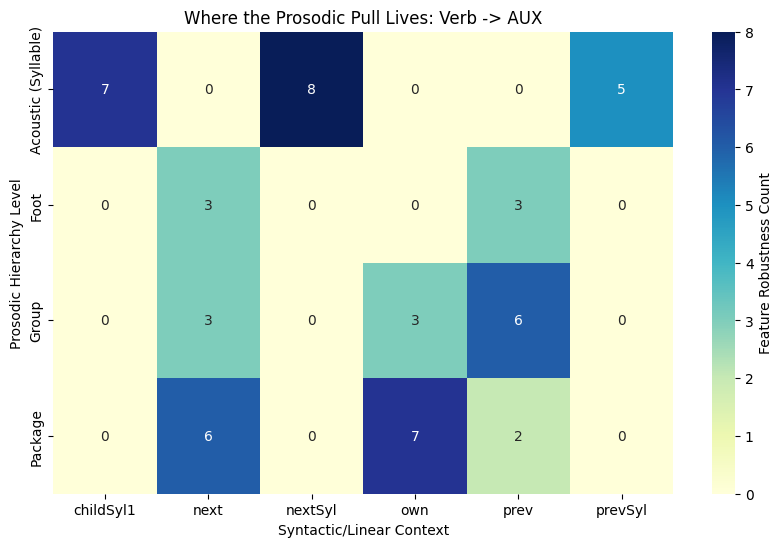

In [132]:
# Pivot to get a matrix of Context vs. Prosodic Level
pivot_df = df_analysis.pivot_table(
    index='level', 
    columns='context', 
    values='count_words', # or 'avg_unit_value'
    aggfunc='sum'
).fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt="g", cbar_kws={'label': 'Feature Robustness Count'})
plt.title("Where the Prosodic Pull Lives: Verb -> AUX")
plt.ylabel("Prosodic Hierarchy Level")
plt.xlabel("Syntactic/Linear Context")
plt.show()

In [133]:
# Filter your df_analysis to see the dominant structural features on 'own'
print("--- Highly Diagnostic 'Group' and 'Period' Features on 'own' ---")
diagnostic_structural = df_analysis[
    (df_analysis['context'] == 'own') & 
    (df_analysis['level'].isin(['Group', 'Period']))
].sort_values(by='count_words', ascending=False)

print(diagnostic_structural[['feature', 'count_words', 'avg_unit_value']].head(10).to_string(index=False))

print("\n--- Highly Diagnostic Acoustic Features on the Word's Syllables ---")
diagnostic_acoustic = df_analysis[
    (df_analysis['context'].isin(['childSyl1', 'childSyl2'])) & 
    (df_analysis['level'] == 'Acoustic (Syllable)')
].sort_values(by='count_words', ascending=False)

print(diagnostic_acoustic[['feature', 'count_words', 'avg_unit_value']].head(10).to_string(index=False))

--- Highly Diagnostic 'Group' and 'Period' Features on 'own' ---
                     feature  count_words  avg_unit_value
node:X:own:GroupTone:start=m            3            0.75

--- Highly Diagnostic Acoustic Features on the Word's Syllables ---
                         feature  count_words  avg_unit_value
  node:X:childSyl1:SlopeGlo=Flat            3        0.907407
node:X:childSyl1:PitchRangeGlo=L            2        1.000000
 node:X:childSyl1:AvgHeightGlo=M            2        1.000000


In [134]:
print(pivot_df)

context              childSyl1  next  nextSyl  own  prev  prevSyl
level                                                            
Acoustic (Syllable)        7.0   0.0      8.0  0.0   0.0      5.0
Foot                       0.0   3.0      0.0  0.0   3.0      0.0
Group                      0.0   3.0      0.0  3.0   6.0      0.0
Package                    0.0   6.0      0.0  7.0   2.0      0.0


In [135]:
def _cell_of(feature_str):
    p = parse_feature_string(feature_str)
    return p["context"], p["level"]
 
 
def background_cell_counts(idx2feature, feature_mask):
    rows = []
    for i, feat in idx2feature.items():
        if feature_mask is not None and not feature_mask[i]:
            continue
        ctx, lvl = _cell_of(feat)
        rows.append({"context": ctx, "level": lvl})
    return (pd.DataFrame(rows)
              .pivot_table(index="level", columns="context",
                           aggfunc="size", fill_value=0))
 
 
def observed_over_expected(df_surfaced, idx2feature, feature_mask,
                           value="total_contrib"):
    """Returns (observed, expected, ratio) DataFrames indexed level × context."""
    parsed = pd.DataFrame([parse_feature_string(f) for f in df_surfaced["feature"]])
    obs_df = parsed[["context", "level"]].copy()
    obs_df["_mass"] = np.asarray(df_surfaced[value].values).ravel()
    observed = obs_df.pivot_table(index="level", columns="context",
                                  values="_mass", aggfunc="sum", fill_value=0.0)
 
    bg = background_cell_counts(idx2feature, feature_mask)
    observed, bg = observed.align(bg, fill_value=0.0)
 
    total_obs, total_bg = observed.values.sum(), bg.values.sum()
    if total_obs == 0 or total_bg == 0:
        return observed, bg * 0.0, observed * 0.0
 
    expected = (bg / total_bg) * total_obs
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = (observed / expected).replace([np.inf, -np.inf], np.nan)
    return observed, expected, ratio

In [138]:
# Each index sums the coverage of the columns whose names contain any of its
# substrings, giving a per-unit RATE for that prosodic property. Confirm the
# substrings hit real columns with the audit cell below before trusting the plot.
 
INDEX_DEFS = {
    "weak foot":            [":own:FootType=Weak"],
    "non-final in group":   [":own:Group=Begin", ":own:Group=In"],
    "non-final in package": [":own:Package=Begin", ":own:Package=In"],
    "weak final prominence":[":own:ProminenceFinal=Weak"],
    "no salient peak":      [":own:FootTone:has_peak=False",
                             ":own:GroupTone:has_peak=False"],
    "short syllables":      [":childSyl1:Duration=Dur_short",
                             ":childSyl2:Duration=Dur_short"],
}
 
 
def audit_index_columns(idx2feature, feature_mask, index_defs=INDEX_DEFS):
    active = {i: f for i, f in idx2feature.items()
              if feature_mask is None or feature_mask[i]}
    for name, subs in index_defs.items():
        hits = sorted({f for f in active.values() if any(s in f for s in subs)})
        print(f"{name:<24} → {len(hits)} column(s)")
        for h in hits:
            print(f"    {h}")
 
 
print("Index → columns matched in the prosody_pure space:\\n")
audit_index_columns(idx2feature, SPACE_MASKS["prosody_pure"])

Index → columns matched in the prosody_pure space:\n
weak foot                → 1 column(s)
    node:X:own:FootType=Weak
non-final in group       → 2 column(s)
    node:X:own:Group=Begin
    node:X:own:Group=In
non-final in package     → 2 column(s)
    node:X:own:Package=Begin
    node:X:own:Package=In
weak final prominence    → 1 column(s)
    node:X:own:ProminenceFinal=Weak
no salient peak          → 0 column(s)
short syllables          → 2 column(s)
    node:X:childSyl1:Duration=Dur_short
    node:X:childSyl2:Duration=Dur_short


In [139]:
def unit_indices(lex_units, feature_matrix, lexunit2idx, idx2feature,
                 index_defs=INDEX_DEFS):
    name2cols = {name: [i for i, f in idx2feature.items()
                        if any(s in f for s in subs)]
                 for name, subs in index_defs.items()}
    rows = []
    for lu in lex_units:
        if lu not in lexunit2idx:
            continue
        vec = feature_matrix[lexunit2idx[lu]]
        row = {"word": lu[0], "pos": lu[1]}
        for name, cols in name2cols.items():
            row[name] = float(vec[cols].sum()) if cols else np.nan
        rows.append(row)
    return pd.DataFrame(rows)
 
 
def build_three_groups(scores_dict, original_cat, rival_cat,
                       lexunit2idx, n_bridge=40, stable_purity=0.8):
    bridge = [(w, original_cat)
              for w, _p, _e in get_top_bridge_words(scores_dict, original_cat,
                                                    rival_cat, top_n=n_bridge)
              if (w, original_cat) in lexunit2idx]
    rival, stable = [], []
    for (word, cat), d in scores_dict.items():
        if cat == rival_cat:
            rival.append((word, cat))
        elif cat == original_cat and d["purity"] >= stable_purity:
            stable.append((word, cat))
    return bridge, rival, stable
 
 
SPACE        = "prosody_pure"
ORIGINAL_CAT = "VERB"
RIVAL_CAT    = "AUX"
 
bridge, rival, stable = build_three_groups(
    scores_by_space[SPACE], ORIGINAL_CAT, RIVAL_CAT,
    lexunit2idx, n_bridge=40, stable_purity=0.8,
)
print(f"bridge {ORIGINAL_CAT}: {len(bridge)}   "
      f"{RIVAL_CAT}: {len(rival)}   stable {ORIGINAL_CAT}: {len(stable)}")
 
frames = []
for gname, group in [(f"bridge {ORIGINAL_CAT}", bridge),
                     (RIVAL_CAT, rival),
                     (f"stable {ORIGINAL_CAT}", stable)]:
    d = unit_indices(group, feature_matrix, lexunit2idx, idx2feature)
    d["group"] = gname
    frames.append(d)
 
group_df = pd.concat(frames, ignore_index=True)
group_order = [f"bridge {ORIGINAL_CAT}", RIVAL_CAT, f"stable {ORIGINAL_CAT}"]
means = group_df.groupby("group")[list(INDEX_DEFS)].mean().reindex(group_order)
print("\\nMean index value per group:")
print(means.round(3).to_string())

bridge VERB: 40   AUX: 40   stable VERB: 68
\nMean index value per group:
             weak foot  non-final in group  non-final in package  weak final prominence  no salient peak  short syllables
group                                                                                                                    
bridge VERB      0.542               0.608                 0.820                  0.291              NaN            0.700
AUX              0.632               0.626                 0.871                  0.284              NaN            0.630
stable VERB      0.489               0.397                 0.676                  0.419              NaN            0.618


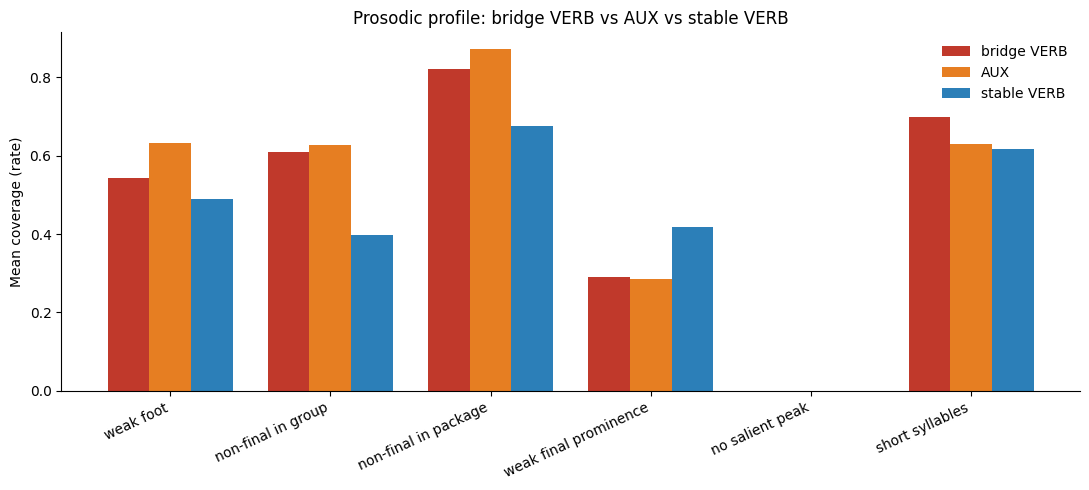

In [140]:
indices = list(INDEX_DEFS)
x = np.arange(len(indices))
width = 0.26
colors = {f"bridge {ORIGINAL_CAT}": "#c0392b",
          RIVAL_CAT:                "#e67e22",
          f"stable {ORIGINAL_CAT}": "#2c7fb8"}
 
fig, ax = plt.subplots(figsize=(11, 5))
for k, gname in enumerate(group_order):
    ax.bar(x + (k - 1) * width, means.loc[gname].values, width,
           label=gname, color=colors[gname])
ax.set_xticks(x)
ax.set_xticklabels(indices, rotation=25, ha="right")
ax.set_ylabel("Mean coverage (rate)")
ax.set_title(f"Prosodic profile: bridge {ORIGINAL_CAT} vs {RIVAL_CAT} "
             f"vs stable {ORIGINAL_CAT}")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

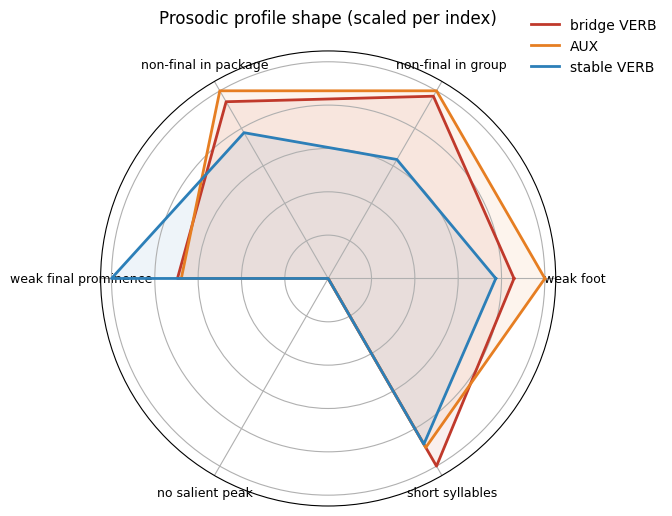

In [141]:
labels = list(INDEX_DEFS)
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
 
# Scale each index to [0, 1] across groups so axes are comparable.
scaled = means.copy()
for col in labels:
    hi = scaled[col].max()
    scaled[col] = scaled[col] / hi if hi > 0 else 0.0
 
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for gname in group_order:
    vals = scaled.loc[gname, labels].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, label=gname, color=colors[gname], linewidth=2)
    ax.fill(angles, vals, color=colors[gname], alpha=0.08)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels([])
ax.set_title(f"Prosodic profile shape (scaled per index)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=False)
plt.tight_layout()
plt.show()

groups: 158 stable VERB, 40 bridge VERB, 48 AUX
93 features separate the poles by >= 0.1
median bridge_position on those features: 0.77  (0 = like stable VERB, 1 = like AUX)

top separating features:

                                           feature  mean_VERB_stable  mean_VERB_bridge  mean_AUX  separation  abs_separation  bridge_position
                             node:X:own:Group=Last             0.665             0.322     0.287      -0.378           0.378            0.908
                           node:X:next:Group=Begin             0.509             0.208     0.145      -0.364           0.364            0.828
                  node:X:childSyl3:PitchRangeGlo=L             0.335             0.080     0.004      -0.332           0.332            0.769
                            node:X:next:Group=Last             0.082             0.355     0.393       0.311           0.311            0.877
                               node:X:own:Group=In             0.206             0.462   

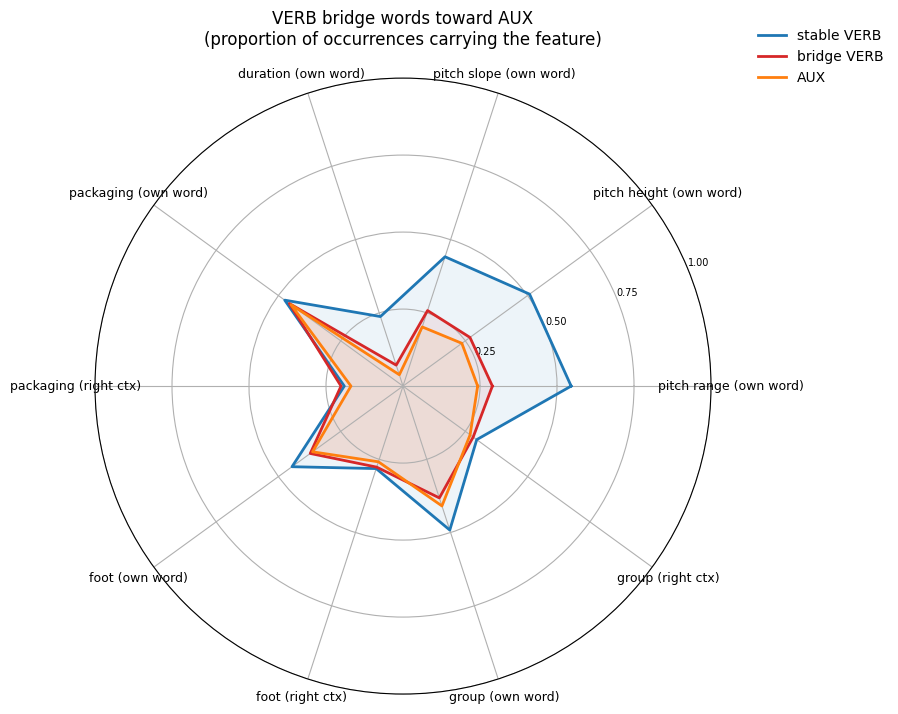

In [171]:
# =============================================================================
# Replaces the hand-written INDEX_DEFS with axes derived from the data.
#
# Idea: find the features on which the ORIGINAL category and the RIVAL category
# genuinely differ, then measure where the bridge words sit between them.
#   position = 0.0  -> bridge words behave like a typical ORIGINAL-category word
#   position = 1.0  -> bridge words behave like a typical RIVAL-category word
# Features where ORIGINAL and RIVAL barely differ are dropped: they cannot
# explain anything, however much they contribute to cosine similarity.
# =============================================================================

import re
import numpy as np
import pandas as pd


def _row_ids(pred):
    return np.array([i for i, lu in idx2lexunit.items() if pred(lu)], dtype=int)


def bridge_contrast(original_cat, rival_cat, space="prosody_pure",
                    n_bridge=40, stable_quantile=0.75, min_separation=0.10):
    """Rank features by how well they separate original_cat from rival_cat,
    and locate the bridge words on each.

    Returns one row per feature with the three group means, the separation
    between the poles, and the bridge words' interpolated position.
    """
    scores = scores_by_space[space]

    # --- three groups -------------------------------------------------------
    bridge_words = get_top_bridge_words(scores, original_cat, rival_cat,
                                        top_n=n_bridge)
    bridge_units = {(d[0], original_cat) for d in bridge_words}
    bridge_ids = np.array([lexunit2idx[u] for u in bridge_units
                           if u in lexunit2idx], dtype=int)

    # Stable = same category, high purity, and NOT pulled toward the rival.
    same_cat = [(lu, scores[lu]["purity"]) for lu in scores
                if lu[1] == original_cat and scores[lu]["rival_category"] != rival_cat]
    if not same_cat:
        raise ValueError(f"no stable {original_cat} units found")
    cutoff = np.quantile([p for _, p in same_cat], stable_quantile)
    stable_ids = np.array([lexunit2idx[lu] for lu, p in same_cat if p >= cutoff],
                          dtype=int)

    rival_ids = _row_ids(lambda lu: lu[1] == rival_cat)

    # --- restrict to the active feature space -------------------------------
    col_mask = SPACE_MASKS[space]
    cols = np.arange(feature_matrix.shape[1]) if col_mask is None \
        else np.where(col_mask)[0]
    names = [idx2feature[c] for c in cols]
    X = feature_matrix[:, cols]

    m_stable = X[stable_ids].mean(axis=0)
    m_bridge = X[bridge_ids].mean(axis=0)
    m_rival = X[rival_ids].mean(axis=0)

    sep = m_rival - m_stable
    with np.errstate(divide="ignore", invalid="ignore"):
        pos = np.where(np.abs(sep) > 1e-9, (m_bridge - m_stable) / sep, np.nan)

    df = pd.DataFrame({
        "feature": names,
        f"mean_{original_cat}_stable": m_stable,
        f"mean_{original_cat}_bridge": m_bridge,
        f"mean_{rival_cat}": m_rival,
        "separation": sep,
        "abs_separation": np.abs(sep),
        "bridge_position": pos,
    })
    df = df[df["abs_separation"] >= min_separation]
    df = df.sort_values("abs_separation", ascending=False).reset_index(drop=True)

    print(f"groups: {len(stable_ids)} stable {original_cat}, "
          f"{len(bridge_ids)} bridge {original_cat}, {len(rival_ids)} {rival_cat}")
    print(f"{len(df)} features separate the poles by >= {min_separation}")
    if len(df):
        print(f"median bridge_position on those features: "
              f"{df['bridge_position'].median():.2f}  "
              f"(0 = like stable {original_cat}, 1 = like {rival_cat})")
    return df


# =============================================================================
# Build the radar axes from the surviving features instead of by hand.
# Features are grouped by (prosodic dimension, position slot), and only groups
# that actually survived the separation filter become axes.
# =============================================================================

DIMENSIONS = {
    "pitch range":   ["PitchRangeGlo"],
    "pitch height":  ["AvgHeightGlo"],
    "pitch slope":   ["SlopeGlo"],
    "duration":      ["Duration"],
    "packaging":     ["Package"],
    "foot":          ["Foot"],
    "group":         ["Group", "RhythmGroup"],
    "period":        ["Period"],
    "prominence":    ["Prominence"],
}
SLOTS = {
    "own word":  ["childSyl", ":own:"],
    "left ctx":  ["prevSyl", ":prev:"],
    "right ctx": ["nextSyl", ":next:"],
}


def derive_index_defs(df, top_n=30, min_features=2):
    """Group the strongest separating features into named axes."""
    top = df.head(top_n)
    axes = {}
    for dim, dpats in DIMENSIONS.items():
        for slot, spats in SLOTS.items():
            hits = [f for f in top["feature"]
                    if any(d in f for d in dpats) and any(s in f for s in spats)]
            if len(hits) >= min_features:
                axes[f"{dim} ({slot})"] = hits
    print(f"derived {len(axes)} axes from the top {top_n} separating features:")
    for name, feats in axes.items():
        print(f"  {name:26s} {len(feats)} features")
        for f in feats:
            print(f"      {f.replace('node:X:', '')}")
    covered = {f for feats in axes.values() for f in feats}
    print(f"\ncoverage: {len(covered)}/{len(top)} of the top features")
    return axes


# =============================================================================
# Radar chart on ABSOLUTE values.
#
# feature_matrix entries are already proportions in [0, 1] — the share of a
# unit's occurrences carrying that feature. Dividing each axis by its own
# maximum (as the earlier script did) throws that away: a 0.80 / 0.78 / 0.76
# split and a 0.80 / 0.10 / 0.05 split both render as an identical shape.
# Plotting the raw means keeps the axes comparable and honest.
# =============================================================================

def plot_profiles(df, axes, original_cat, rival_cat, ax=None):
    import matplotlib.pyplot as plt

    cols = [f"mean_{original_cat}_stable",
            f"mean_{original_cat}_bridge",
            f"mean_{rival_cat}"]
    labels = [f"stable {original_cat}", f"bridge {original_cat}", rival_cat]
    colors = ["tab:blue", "tab:red", "tab:orange"]

    idx = df.set_index("feature")
    names = list(axes)
    means = {c: [idx.loc[axes[n], c].mean() for n in names] for c in cols}

    ang = np.linspace(0, 2 * np.pi, len(names), endpoint=False).tolist()
    ang += ang[:1]
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for c, lab, col in zip(cols, labels, colors):
        v = means[c] + means[c][:1]
        ax.plot(ang, v, label=lab, color=col, linewidth=2)
        ax.fill(ang, v, color=col, alpha=0.08)
    ax.set_xticks(ang[:-1])
    ax.set_xticklabels(names, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7)
    ax.set_title(f"{original_cat} bridge words toward {rival_cat}\n"
                 f"(proportion of occurrences carrying the feature)", pad=24)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), frameon=False)
    return ax


# =============================================================================
# Run it.
# =============================================================================

df = bridge_contrast("VERB", "AUX", space="prosody_pure")
print("\ntop separating features:\n")
print(df.head(25).round(3).to_string(index=False))

axes = derive_index_defs(df)
plot_profiles(df, axes, "VERB", "AUX")

# Sanity check before trusting any of it: if the bridge words do NOT sit
# between the two poles, the "bridge" framing does not hold for this pair.
print(f"\nfeatures where bridge sits between the poles (0 <= position <= 1): "
      f"{df['bridge_position'].between(0, 1).mean():.1%}")

In [169]:
# =============================================================================
# Revised bridge_contrast.
#
# Changes from the previous version:
#   1. reference= chooses how the two poles are defined:
#        "centroid"      - mean over all units of the category, bridge words
#                          excluded so the pole is not contaminated by them
#        "purity_weighted" - same, but each unit weighted by its purity, so
#                          prototypical members count more
#        "high_purity"   - the old top-quantile subset, kept for comparison
#      The dubious "rival_category != rival_cat" filter is gone entirely:
#      purity already measures prototypicality, and that filter was discarding
#      good stable verbs whose weak second rival happened to be AUX.
#   2. Both poles get the same treatment (symmetric by default).
#   3. Features whose value is near-zero for one pole because the syllable
#      does not exist are flagged as length proxies rather than reported as
#      pitch or duration effects.
# =============================================================================

import re
import numpy as np
import pandas as pd

SYL_SLOT_RE = re.compile(r"childSyl(\d+):")


def _pole(cat, exclude_ids, reference, scores, quantile):
    """Row indices and weights defining one end of the contrast."""
    ids = np.array([i for i, lu in idx2lexunit.items()
                    if lu[1] == cat and i not in exclude_ids], dtype=int)
    if len(ids) == 0:
        raise ValueError(f"no units left for {cat}")

    if reference == "centroid":
        return ids, np.ones(len(ids))

    pur = np.array([scores.get(idx2lexunit[i], {}).get("purity", 0.0) for i in ids])

    if reference == "purity_weighted":
        return ids, pur

    if reference == "high_purity":
        keep = pur >= np.quantile(pur, quantile)
        return ids[keep], np.ones(int(keep.sum()))

    raise ValueError(f"unknown reference: {reference}")


def bridge_contrast(original_cat, rival_cat, space="prosody_pure",
                    n_bridge=40, reference="centroid", quantile=0.75,
                    min_separation=0.10, flag_length_proxies=True):
    scores = scores_by_space[space]

    bridge_units = {(d[0], original_cat)
                    for d in get_top_bridge_words(scores, original_cat,
                                                  rival_cat, top_n=n_bridge)}
    bridge_ids = np.array([lexunit2idx[u] for u in bridge_units
                           if u in lexunit2idx], dtype=int)
    excl = set(bridge_ids.tolist())

    orig_ids, orig_w = _pole(original_cat, excl, reference, scores, quantile)
    rival_ids, rival_w = _pole(rival_cat, excl, reference, scores, quantile)

    col_mask = SPACE_MASKS[space]
    cols = (np.arange(feature_matrix.shape[1]) if col_mask is None
            else np.where(col_mask)[0])
    names = [idx2feature[c] for c in cols]
    X = feature_matrix[:, cols]

    m_orig = np.average(X[orig_ids], axis=0, weights=orig_w)
    m_rival = np.average(X[rival_ids], axis=0, weights=rival_w)
    m_bridge = X[bridge_ids].mean(axis=0)

    sep = m_rival - m_orig
    with np.errstate(divide="ignore", invalid="ignore"):
        pos = np.where(np.abs(sep) > 1e-9, (m_bridge - m_orig) / sep, np.nan)

    # A childSylN feature is a length proxy when one pole almost never has
    # syllable N at all: the contrast is then "does the word have N syllables",
    # not "what does syllable N sound like".
    slot = [int(m.group(1)) if (m := SYL_SLOT_RE.search(f)) else 0 for f in names]
    is_proxy = np.array([
        s >= 2 and (mo < 0.05 or mr < 0.05)
        for s, mo, mr in zip(slot, m_orig, m_rival)
    ])

    df = pd.DataFrame({
        "feature": names,
        f"mean_{original_cat}": m_orig,
        "mean_bridge": m_bridge,
        f"mean_{rival_cat}": m_rival,
        "separation": sep,
        "abs_separation": np.abs(sep),
        "bridge_position": pos,
        "syl_slot": slot,
        "length_proxy": is_proxy,
    })
    df = df[df["abs_separation"] >= min_separation]
    df = df.sort_values("abs_separation", ascending=False).reset_index(drop=True)

    n_proxy = int(df["length_proxy"].sum())
    print(f"reference = {reference}")
    print(f"poles: {len(orig_ids)} {original_cat}, {len(rival_ids)} {rival_cat}; "
          f"{len(bridge_ids)} bridge words (excluded from both poles)")
    print(f"{len(df)} features separate the poles by >= {min_separation}")
    if n_proxy:
        print(f"  !! {n_proxy} of them are LENGTH PROXIES "
              f"(a childSyl slot one pole essentially never fills)")
        print(f"     e.g. {', '.join(df.loc[df['length_proxy'], 'feature'].head(4).str.replace('node:X:', '', regex=False))}")
    clean = df[~df["length_proxy"]] if flag_length_proxies else df
    print(f"median bridge_position, length proxies excluded: "
          f"{clean['bridge_position'].median():.2f}  "
          f"(0 = like {original_cat}, 1 = like {rival_cat})")
    print(f"share sitting between the poles: "
          f"{clean['bridge_position'].between(0, 1).mean():.1%}")
    return df


# =============================================================================
# Recommended run for VERB -> AUX.
#
# Three checks, in order:
#   1. does the story depend on how the poles are defined?
#   2. does the position-in-unit story survive with length features removed?
#   3. does it survive for semi-auxiliaries only, whose word forms are
#      DISTINCT from the AUX inventory?
# =============================================================================

for ref in ["centroid", "purity_weighted", "high_purity"]:
    print(f"\n===== {ref} =====")
    bridge_contrast("VERB", "AUX", reference=ref)

print("\n===== length-blind space (childSyl2+ columns dropped) =====")
df_clean = bridge_contrast("VERB", "AUX", space="prosody_pure")
print(df_clean.head(20).round(3).to_string(index=False))

# --- the form-identity check -------------------------------------------------
# Half the bridge list are avoir/etre forms that are ALSO the word forms of
# actual auxiliaries. A sceptic says the result is form identity, not category
# gradience. The semi-auxiliaries (aller, pouvoir, devoir, vouloir, falloir,
# sembler) share no forms with the AUX inventory, so they are the clean test.
SEMI_AUX = {"va", "vas", "allez", "allait", "allons", "vont",
            "peut", "pourrait", "peux", "pouvait",
            "doit", "dois", "devait", "veux", "veut", "voulait",
            "faut", "fallait", "semblait", "semble"}
AVOIR_ETRE = {"a", "ai", "as", "ont", "avait", "avaient", "avoir", "eu", "a~",
              "est", "es", "sont", "etait", "été", "être", "suis"}

bw = [d[0] for d in get_top_bridge_words(
    scores_by_space["prosody_pure"], "VERB", "AUX", top_n=40)]
print(f"\nbridge list: {len(set(bw) & AVOIR_ETRE)} avoir/etre forms, "
      f"{len(set(bw) & SEMI_AUX)} semi-auxiliaries, "
      f"{len(set(bw) - AVOIR_ETRE - SEMI_AUX)} other")
print("  other:", sorted(set(bw) - AVOIR_ETRE - SEMI_AUX))


===== centroid =====
reference = centroid
poles: 1342 VERB, 48 AUX; 40 bridge words (excluded from both poles)
58 features separate the poles by >= 0.1
  !! 8 of them are LENGTH PROXIES (a childSyl slot one pole essentially never fills)
     e.g. childSyl3:PitchRangeGlo=L, childSyl3:AvgHeightGlo=M, childSyl3:SlopeGlo=Flat, childSyl2:AvgHeightGlo=H
median bridge_position, length proxies excluded: 0.83  (0 = like VERB, 1 = like AUX)
share sitting between the poles: 80.0%

===== purity_weighted =====
reference = purity_weighted
poles: 1342 VERB, 48 AUX; 40 bridge words (excluded from both poles)
89 features separate the poles by >= 0.1
  !! 7 of them are LENGTH PROXIES (a childSyl slot one pole essentially never fills)
     e.g. childSyl3:PitchRangeGlo=L, childSyl3:AvgHeightGlo=M, childSyl3:SlopeGlo=Flat, childSyl3:Duration=Dur_mid
median bridge_position, length proxies excluded: 0.73  (0 = like VERB, 1 = like AUX)
share sitting between the poles: 74.4%

===== high_purity =====
reference

In [142]:
def calculate_weighted_stability(transition_matrix, category_counts):
    """Weighted average of the diagonal of the transition matrix.

    transition_matrix : square, row-stochastic, indexed by POS.
    category_counts   : dict / Series mapping POS → token count (or any
                         consistent weight).
    """
    categories = transition_matrix.index
    stability_scores = pd.Series(np.diag(transition_matrix), index=categories)
    weights = pd.Series(category_counts).reindex(categories).fillna(0)
    total_weight = weights.sum()
    if total_weight == 0:
        return 0.0
    return (stability_scores * weights).sum() / total_weight


# WAS for every feature space.
for space, tm in transition_matrices.items():
    was = calculate_weighted_stability(tm, category_freqs)
    print(f"WAS ({space:<9}): {was:.4f}")


WAS (syntactic): 0.1295
WAS (prosodic_syntactic): 0.2572
WAS (prosody_pure): 0.1992
WAS (combined ): 0.2583


In [143]:
# ── Prosodic profile & contour sketch ─────────────────────────────────────
# Turn a pulling-features DataFrame into (a) a compact profile table indexed
# by acoustic dimension × syllable position, and (b) a schematic pitch
# contour drawn as line segments across the prev / own / next syllables.
# The idea is to make cross-category overlaps interpretable at a glance,
# rather than reading raw feature lists.

import matplotlib.pyplot as plt


def _parse_feature(feat):
    """'node:X:childSyl1:AvgHeightGlo=M' → ('childSyl1', 'AvgHeightGlo', 'M')."""
    if not feat.startswith('node:X:') or '=' not in feat:
        return None
    lhs, val = feat[len('node:X:'):].rsplit('=', 1)
    parts = lhs.split(':')
    if len(parts) < 2:
        return None
    return parts[0], ':'.join(parts[1:]), val


# Syllable positions in temporal order (prev → own → next).
SYLLABLE_POSITIONS = ('prev', 'prevSyl', 'own' 'childSyl1', 'childSyl2', 'childSyl3', 'nextSyl', 'next')

# Group the many prosodic feature dimensions into interpretable acoustic
# categories. The Glo / Loc variants (global vs local scope) are lumped
# together since they measure the same underlying acoustic property.
DIM_GROUPS = {
    'pitch height': ('AvgHeightGlo', 'AvgHeightLoc',
                     'SemitonesFromUtteranceMean', 'MeanF0', 'MeanF0Step'),
    'pitch range':  ('PitchRangeGlo', 'PitchRangeLoc'),
    'slope':        ('Slope', 'SlopeGlo', 'SlopeLoc'),
    'duration':     ('Duration',),
    'amplitude':    ('AvgAmplitude', 'MaxAmplitude'),
}
_dim_to_group = {d: g for g, dims in DIM_GROUPS.items() for d in dims}


def _classify(feat):
    """(position, group, dimension, value) if this is a syllable-level feature."""
    p = _parse_feature(feat)
    if p is None:
        return None
    position, dimension, value = p
    if position not in SYLLABLE_POSITIONS:
        return None
    group = _dim_to_group.get(dimension)
    if group is None:
        return None
    return position, group, dimension, value


def build_profile_table(pulling_df, top_k_per_cell=2):
    """
    From a pulling-features DataFrame, produce a compact table indexed by
    acoustic dimension × syllable position. Each cell shows the top-k
    dominant feature values, ranked by aggregate weight (avg_unit_value ×
    count_words).
    """
    rows = []
    for _, r in pulling_df.iterrows():
        cls = _classify(r['feature'])
        if cls is None:
            continue
        pos, group, _, value = cls
        rows.append({
            'position': pos, 'group': group, 'value': value,
            'weight': r['avg_unit_value'] * r['count_words'],
        })
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)

    positions_seen = [p for p in SYLLABLE_POSITIONS if p in df['position'].unique()]
    groups_seen    = [g for g in DIM_GROUPS       if g in df['group'].unique()]

    table = pd.DataFrame(index=groups_seen, columns=positions_seen, dtype=object)
    for group in groups_seen:
        for pos in positions_seen:
            sub = df[(df['position'] == pos) & (df['group'] == group)]
            if sub.empty:
                table.loc[group, pos] = '—'
            else:
                agg = sub.groupby('value')['weight'].sum().sort_values(ascending=False)
                table.loc[group, pos] = ', '.join(agg.head(top_k_per_cell).index.tolist())
    return table


# Numeric mappings for drawing the sketch.
_HEIGHT   = {'L': 1, 'M': 2, 'H': 3,
             'F0_low': 1, 'F0_mid': 2, 'F0_high': 3}
_DURATION = {'Dur_short': 0.5, 'Dur_mid': 0.8, 'Dur_long': 1.2}
_SLOPE    = {'Flat': 0.0, 'Rise': 0.5, 'Fall': -0.5}
_RANGE    = {'L': 0.35, 'M': 0.60, 'H': 0.90}



def _profile_with_confidence(pulling_df):
    """Return {position: {group: {'top', 'alt', 'confidence'}}}.
 
    `confidence` is the top value's share of the total weight for that
    (position, group). A confidence of 1.0 means one value dominates
    completely; 0.5 means the top and alt are tied.
    """
    rows = []
    for _, r in pulling_df.iterrows():
        cls = _classify(r['feature'])
        if cls is None:
            continue
        pos, group, _, value = cls
        rows.append({
            'position': pos, 'group': group, 'value': value,
            'weight': r['avg_unit_value'] * r['count_words'],
        })
    if not rows:
        return {}
    df = pd.DataFrame(rows)
    result = {}
    for (pos, group), sub in df.groupby(['position', 'group']):
        agg = sub.groupby('value')['weight'].sum().sort_values(ascending=False)
        top_val = agg.index[0]
        top_w   = agg.iloc[0]
        total   = agg.sum()
        confidence = top_w / total if total > 0 else 1.0
        alt_val = agg.index[1] if len(agg) > 1 else None
        result.setdefault(pos, {})[group] = {
            'top': top_val, 'alt': alt_val, 'confidence': float(confidence),
        }
    return result


# def _dominant_values(pulling_df):
#     """Return {position: {group: dominant_value}} from pulling features."""
#     rows = []
#     for _, r in pulling_df.iterrows():
#         cls = _classify(r['feature'])
#         if cls is None:
#             continue
#         pos, group, _, value = cls
#         rows.append({
#             'position': pos, 'group': group, 'value': value,
#             'weight': r['avg_unit_value'] * r['count_words'],
#         })
#     if not rows:
#         return {}
#     df = pd.DataFrame(rows)
#     result = {}
#     for (pos, group), sub in df.groupby(['position', 'group']):
#         top_value = sub.groupby('value')['weight'].sum().idxmax()
#         result.setdefault(pos, {})[group] = top_value
#     return result


def sketch_contour(pulling_df, title=None, ax=None,
                   uncertainty_threshold=0.65, show_uncertainty=True):
    """
    Draw a schematic prosodic contour from a pulling-features DataFrame.
    Each syllable becomes a line segment:
      - horizontal position and width : temporal order + duration
      - vertical position             : pitch height
      - line slope                    : direction (rise / flat / fall)
      - shaded band                   : pitch range around the pitch trajectory
 
    When a (syllable, dimension) has a top value that doesn't clearly
    dominate (confidence < `uncertainty_threshold`), the alternative
    value is shown as a lighter dashed indicator:
      - alt slope    → dashed line at the alternative trajectory
      - alt duration → dashed vertical tick at the alternative endpoint
      - alt height   → dashed horizontal line at the alternative pitch level
    The main solid line is also drawn at reduced opacity to signal that
    the value is contested.
    """
    dom = _profile_with_confidence(pulling_df)
    if not dom:
        print("No syllable-level features found in pulling table.")
        return
 
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 3.6))
 
    x = 0
    for pos in SYLLABLE_POSITIONS:
        if pos not in dom:
            continue
        vals = dom[pos]
 
        def _v(group, default):
            info = vals.get(group)
            if info is None:
                return default, None, 1.0
            return info['top'], info['alt'], info['confidence']
 
        h_val, h_alt, h_conf = _v('pitch height', 'M')
        r_val, _,     _      = _v('pitch range',  'M')
        s_val, s_alt, s_conf = _v('slope',        'Flat')
        d_val, d_alt, d_conf = _v('duration',     'Dur_mid')
 
        h = _HEIGHT.get(h_val, 2)
        w = _DURATION.get(d_val, 0.8)
        s = _SLOPE.get(s_val, 0.0)
        r = _RANGE.get(r_val, 0.5)
        # Compute alt widths
        w_alt = None
        if (show_uncertainty and d_conf < uncertainty_threshold
                and d_alt is not None and d_alt in _DURATION):
            w_alt = _DURATION[d_alt]

        is_own = (pos == 'childSyl1')
        color  = '#2166ac' if is_own else '#67a9cf'
        lw     = 4 if is_own else 3
 
        y_start = h - s / 2
        y_end   = h + s / 2
 
        # Pitch range band — wider and with an edge outline for visibility.
        ax.fill_between([x, x + w],
                        [y_start - r/2, y_end - r/2],
                        [y_start + r/2, y_end + r/2],
                        color=color, alpha=0.28,
                        edgecolor=color, linewidth=0.6)
 
        # Alt duration indicator: dashed vertical tick at the alt endpoint,
        # placed just below the range band so it doesn't overlap the pitch line.
        if w_alt is not None:
            tick_x = x + w_alt
            tick_y = y_start - r/2 - 0.04 + (y_end - y_start) * w_alt / w if w > 0 else y_start
            ax.plot([tick_x, tick_x],
                    [tick_y - 0.12, tick_y + 0.08],
                    color=color, linewidth=1.5, alpha=0.6,
                    linestyle=(0, (2, 2)))

        # Main slope line — dimmed if slope is contested
        main_alpha = 0.95 if s_conf >= uncertainty_threshold else 0.65
        ax.plot([x, x + w], [y_start, y_end],
                color=color, linewidth=lw, alpha=main_alpha,
                solid_capstyle='round')

        # Alt slope: dashed line at the alternative trajectory
        if (show_uncertainty and s_conf < uncertainty_threshold
                and s_alt is not None and s_alt in _SLOPE):
            s_alt_val = _SLOPE[s_alt]
            y_alt_start = h - s_alt_val / 2
            y_alt_end   = h + s_alt_val / 2
            ax.plot([x, x + w], [y_alt_start, y_alt_end],
                    color=color, linewidth=lw - 1, alpha=0.4,
                    linestyle=(0, (4, 3)), solid_capstyle='round')

        # Alt pitch height: dashed horizontal at the alt height level
        if (show_uncertainty and h_conf < uncertainty_threshold
                and h_alt is not None and h_alt in _HEIGHT):
            h_alt_val = _HEIGHT[h_alt]
            if abs(h_alt_val - h) >= 1:  # only draw if actually different
                ax.plot([x, x + w], [h_alt_val, h_alt_val],
                        color=color, linewidth=1.5, alpha=0.4,
                        linestyle=(0, (3, 3)))

 
     # Syllable label
        label = {'prevSyl': 'prev', 'childSyl1': 'own',
                 'childSyl2': 'own₂', 'childSyl3': 'own₃',
                 'nextSyl': 'next'}[pos]
        ax.text(x + max(w, w_alt or w) / 2, 0.15, label,
                ha='center', va='center', fontsize=10,
                color=color, weight='bold' if is_own else 'normal')

        # Advance by max of main and alt duration
        x += max(w, w_alt or w) + 0.2
 
    ax.set_ylim(-0.2, 3.8)
    ax.set_xlim(-0.2, max(x, 1))
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(['low', 'mid', 'high'])
    ax.set_ylabel('pitch')
    ax.set_xticks([])
    for spine in ('top', 'right', 'bottom'):
        ax.spines[spine].set_visible(False)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if title:
        ax.set_title(title, fontsize=11, pad=10)
    if standalone:
        plt.tight_layout()

Analyzing 7 bridge words: ['-moi', 'aucun', 'ceci', 'celui-là', 'quand', 'quoi', 'rien']

Acoustic profile of PRON → ADV overlap (prosody_pure):

             prevSyl nextSyl
pitch height       M       M
pitch range        L       L
slope           Flat    Flat



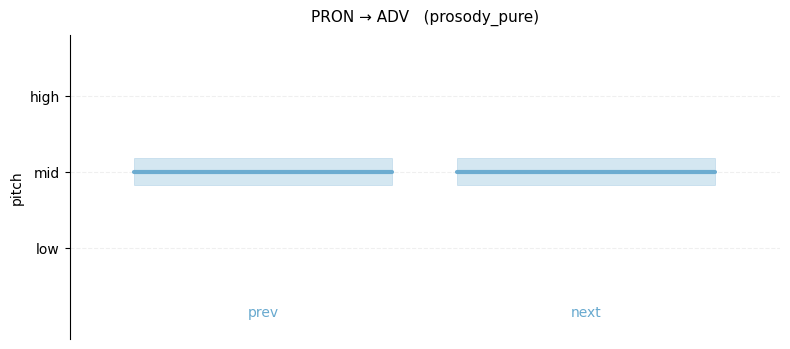

In [144]:
# ── Profile + sketch for a single cross-category overlap ─────────────────
SPACE        = "prosody_pure"
ORIGINAL_CAT = "PRON"
RIVAL_CAT    = "ADV"

df_agg = get_aggregate_pulling_features(
    scores_dict=scores_by_space[SPACE],
    original_cat=ORIGINAL_CAT, rival_cat=RIVAL_CAT,
    feature_matrix=feature_matrix,
    similarity_matrix=similarities[SPACE],
    idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
    idx2feature=idx2feature, feature2idx=feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_words=7, top_k_features=40,
)

profile = build_profile_table(df_agg)
print(f"Acoustic profile of {ORIGINAL_CAT} → {RIVAL_CAT} overlap ({SPACE}):\n")
print(profile.to_string())
print()

sketch_contour(df_agg, title=f"{ORIGINAL_CAT} → {RIVAL_CAT}   ({SPACE})")
plt.show()

Analyzing 7 bridge words: ['-moi', 'aucun', 'ceci', 'celui-là', 'quand', 'quoi', 'rien']

Analyzing 1 bridge words: ['puisque']



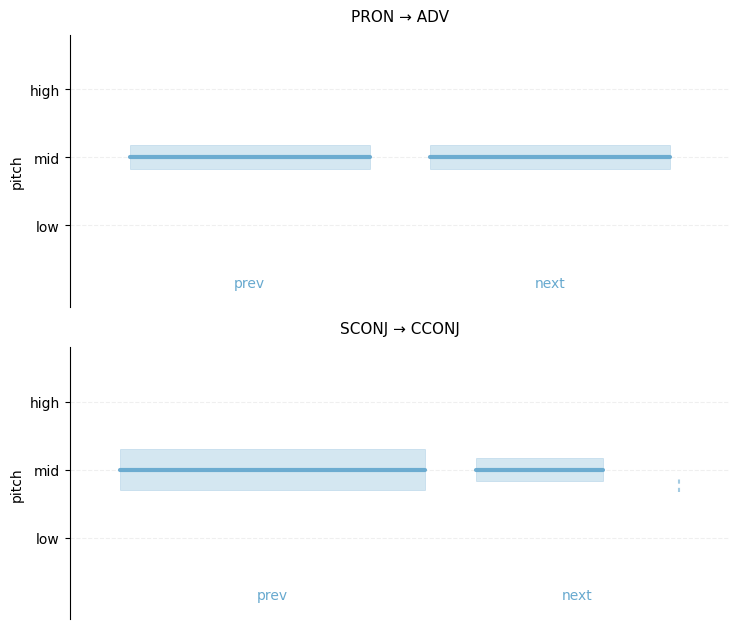

In [145]:
# ── Compare two overlaps side-by-side ─────────────────────────────────────
# Useful for checking whether two rival attractions share the same acoustic
# gesture (e.g. CCONJ → SCONJ vs SCONJ → CCONJ) or diverge.
SPACE = "prosody_pure"
OVERLAPS = [
    ("PRON", "ADV"),
    ("SCONJ", "CCONJ"),
]

fig, axes = plt.subplots(len(OVERLAPS), 1, figsize=(7.5, 3.2 * len(OVERLAPS)),
                         squeeze=False)
for ax, (orig, rival) in zip(axes.flat, OVERLAPS):
    df_agg = get_aggregate_pulling_features(
        scores_dict=scores_by_space[SPACE],
        original_cat=orig, rival_cat=rival,
        feature_matrix=feature_matrix,
        similarity_matrix=similarities[SPACE],
        idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
        idx2feature=idx2feature, feature2idx=feature2idx,
        feature_mask=SPACE_MASKS[SPACE],
        top_k_words=7, top_k_features=40,
    )
    if df_agg is None or df_agg.empty:
        ax.set_title(f"{orig} → {rival}: no bridge words")
        ax.axis('off')
        continue
    sketch_contour(df_agg, title=f"{orig} → {rival}", ax=ax)
plt.tight_layout()
plt.show()

VERB → AUX overlap carried per prosodic level (per-column-corrected):
                     observed_mass  n_columns  per_column
Acoustic (Syllable)         5.8333        140      0.0417
Package                     2.2706        117      0.0194
Group                       1.0701        114      0.0094
Foot                        0.6091        114      0.0053
Period                      0.2433         81      0.0030
Prominence                  0.0000         18      0.0000


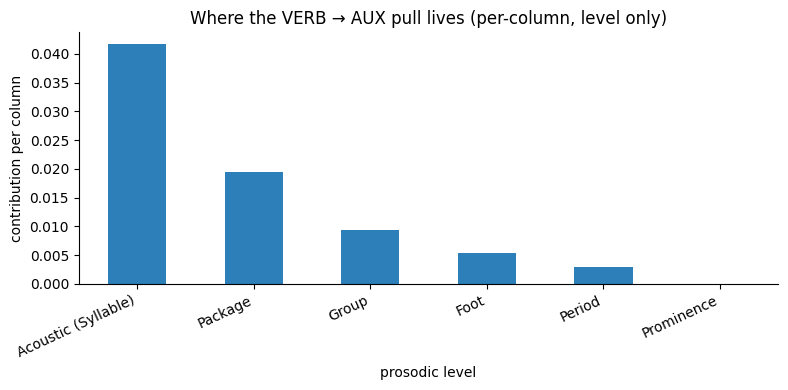

In [146]:
# ═══════════════════════════════════════════════════════════════════════════
# PIECE 2 (revised): collapse to LEVEL only — the 2D grid is confounded by design
# ═══════════════════════════════════════════════════════════════════════════
# context is nearly determined by level (acoustic ⟹ syllable node; structural ⟹
# token node), so the 2D grid mostly recovers the annotation design. Collapsing
# to level and dividing by each level's column budget gives contribution-per-
# column: how much VERB→AUX overlap each level carries per feature it owns.
# NB: still a diagnostic, not a headline — acoustic features are dense (always
# fire) while many structural features are sparse, so per-column mass is not
# perfectly comparable across levels. Read it as "roughly where the pull lives".

def contribution_per_level(df_surfaced, idx2feature, feature_mask,
                           value="total_contrib"):
    # observed contribution mass per level
    parsed = pd.DataFrame([parse_feature_string(f) for f in df_surfaced["feature"]])
    obs = parsed[["level"]].copy()
    obs["_mass"] = np.asarray(df_surfaced[value].values).ravel()
    observed = obs.groupby("level")["_mass"].sum()

    # column budget per level over the active space
    budget = {}
    for i, feat in idx2feature.items():
        if feature_mask is not None and not feature_mask[i]:
            continue
        lvl = parse_feature_string(feat)["level"]
        budget[lvl] = budget.get(lvl, 0) + 1
    budget = pd.Series(budget)

    df = pd.DataFrame({"observed_mass": observed, "n_columns": budget}).fillna(0.0)
    df["per_column"] = df["observed_mass"] / df["n_columns"].replace(0, np.nan)
    return df.sort_values("per_column", ascending=False)


SPACE = "prosody_pure"
level_df = contribution_per_level(df_mass, idx2feature, SPACE_MASKS[SPACE])
print("VERB → AUX overlap carried per prosodic level (per-column-corrected):")
print(level_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
level_df["per_column"].plot.bar(ax=ax, color="#2c7fb8")
ax.set_ylabel("contribution per column")
ax.set_xlabel("prosodic level")
ax.set_title("Where the VERB → AUX pull lives (per-column, level only)")
plt.xticks(rotation=25, ha="right")
sns.despine(); plt.tight_layout(); plt.show()



Index → columns matched (prosody_pure):

weak foot (own)                         → 1 col(s)
      node:X:own:FootType=Weak
short own syllables                     → 2 col(s)
      node:X:childSyl1:Duration=Dur_short
      node:X:childSyl2:Duration=Dur_short
weak final prominence                   → 1 col(s)
      node:X:own:ProminenceFinal=Weak
weak initial prominence                 → 1 col(s)
      node:X:own:ProminenceInitial=Weak
non-final in group                      → 2 col(s)
      node:X:own:Group=Begin
      node:X:own:Group=In
non-final in package                    → 2 col(s)
      node:X:own:Package=Begin
      node:X:own:Package=In
flat own syllables                      → 2 col(s)
      node:X:childSyl1:SlopeGlo=Flat
      node:X:childSyl2:SlopeGlo=Flat
low own syllables                       → 2 col(s)
      node:X:childSyl1:AvgHeightGlo=L
      node:X:childSyl2:AvgHeightGlo=L
salient peak (own)         (complement) → 2 col(s)
      node:X:own:FootTone:has_peak=True
  

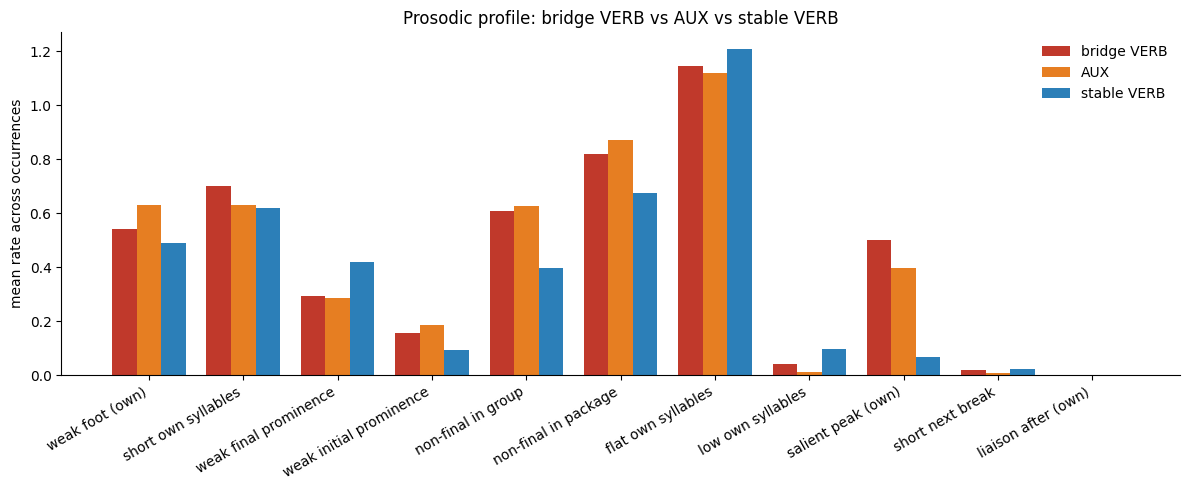

In [147]:
# ═══════════════════════════════════════════════════════════════════════════
# PIECE 3 (revised): occurrence-normalised indices, richer & discriminating
# ═══════════════════════════════════════════════════════════════════════════
# feature_matrix rows are normalised by TOTAL feature mass (cell 12), so values
# are a feature's share of the unit's prosodic mass — compressed by ~1/K and not
# readable as "fraction of occurrences". For the figure we rebuild the indices
# from occurrence counts instead:  rate = co_occurrence[i,j] / n_occ(i), where
# n_occ(i) = len(data[lex_unit]). Then 0.30 == "30% of this unit's occurrences".
# This changes NOTHING upstream (cosine divides out the per-row constant); it
# only puts the figure on an interpretable scale.

# Per-unit occurrence counts, aligned to the co_occurrence_matrix row order.
n_occ = np.array([len(data[idx2lexunit[i]]) for i in range(len(idx2lexunit))],
                 dtype=float)
occ_rate_matrix = co_occurrence_matrix / n_occ[:, None]   # fraction of occurrences

# Indices as (substrings, sign). sign=+1: higher = more function-word-like.
# sign=-1: we take the complement (1 - rate), for properties whose only column
# is the "present" case (e.g. has_peak=True) or that mark content-word behaviour.
INDEX_DEFS = {
    # reduction / unstress
    "weak foot (own)":        ([":own:FootType=Weak"], +1),
    "short own syllables":    ([":childSyl1:Duration=Dur_short",
                                ":childSyl2:Duration=Dur_short"], +1),
    "weak final prominence":  ([":own:ProminenceFinal=Weak"], +1),
    "weak initial prominence":([":own:ProminenceInitial=Weak"], +1),
    # position (proclitic: sits at the start / inside, not phrase-final)
    "non-final in group":     ([":own:Group=Begin", ":own:Group=In"], +1),
    "non-final in package":   ([":own:Package=Begin", ":own:Package=In"], +1),
    # pitch shape: flat, low, no salient peak = function-word-like
    "flat own syllables":     ([":childSyl1:SlopeGlo=Flat",
                                ":childSyl2:SlopeGlo=Flat"], +1),
    "low own syllables":      ([":childSyl1:AvgHeightGlo=L",
                                ":childSyl2:AvgHeightGlo=L"], +1),
    "salient peak (own)":     ([":own:FootTone:has_peak=True",
                                ":own:GroupTone:has_peak=True"], -1),
    # phrasing: short following break = tightly bound to next word
    "short next break":       ([":own:NextBreakLength=NextBreak_short"], +1),
    "liaison after (own)":    ([":own:LiaisonAfter=Yes"], +1),
}


def audit_index_columns(idx2feature, feature_mask, index_defs=INDEX_DEFS):
    active = {i: f for i, f in idx2feature.items()
              if feature_mask is None or feature_mask[i]}
    for name, (subs, sign) in index_defs.items():
        hits = sorted({f for f in active.values() if any(s in f for s in subs)})
        flag = "" if hits else "   <-- NO MATCH, will be NaN"
        print(f"{name:<26} {'(complement)' if sign < 0 else '            '} "
              f"→ {len(hits)} col(s){flag}")
        for h in hits:
            print(f"      {h}")


print("\nIndex → columns matched (prosody_pure):\n")
audit_index_columns(idx2feature, SPACE_MASKS["prosody_pure"])


def unit_indices(lex_units, occ_rate_matrix, lexunit2idx, idx2feature,
                 feature2idx, index_defs=INDEX_DEFS):
    """One row per unit; each index is an occurrence-rate in [0, 1]."""
    name2cols = {name: ([feature2idx[f] for f in idx2feature.values()
                         if any(s in f for s in subs) and f in feature2idx], sign)
                 for name, (subs, sign) in index_defs.items()}
    # resolve column indices via feature strings actually present
    name2cols = {}
    for name, (subs, sign) in index_defs.items():
        cols = [i for i, f in idx2feature.items() if any(s in f for s in subs)]
        name2cols[name] = (cols, sign)

    rows = []
    for lu in lex_units:
        if lu not in lexunit2idx:
            continue
        r = occ_rate_matrix[lexunit2idx[lu]]
        row = {"word": lu[0], "pos": lu[1]}
        for name, (cols, sign) in name2cols.items():
            if not cols:
                row[name] = np.nan
            else:
                rate = float(r[cols].sum())
                row[name] = (1.0 - rate) if sign < 0 else rate
        rows.append(row)
    return pd.DataFrame(rows)


def build_three_groups(scores_dict, original_cat, rival_cat,
                       lexunit2idx, n_bridge=40, stable_purity=0.8):
    bridge = [(w, original_cat)
              for w, _p, _e in get_top_bridge_words(scores_dict, original_cat,
                                                    rival_cat, top_n=n_bridge)
              if (w, original_cat) in lexunit2idx]
    rival, stable = [], []
    for (word, cat), d in scores_dict.items():
        if cat == rival_cat:
            rival.append((word, cat))
        elif cat == original_cat and d["purity"] >= stable_purity:
            stable.append((word, cat))
    return bridge, rival, stable


SPACE, ORIGINAL_CAT, RIVAL_CAT = "prosody_pure", "VERB", "AUX"
bridge, rival, stable = build_three_groups(
    scores_by_space[SPACE], ORIGINAL_CAT, RIVAL_CAT,
    lexunit2idx, n_bridge=40, stable_purity=0.8)
print(f"\nbridge {ORIGINAL_CAT}: {len(bridge)}   {RIVAL_CAT}: {len(rival)}   "
      f"stable {ORIGINAL_CAT}: {len(stable)}")

frames = []
for gname, group in [(f"bridge {ORIGINAL_CAT}", bridge),
                     (RIVAL_CAT, rival),
                     (f"stable {ORIGINAL_CAT}", stable)]:
    d = unit_indices(group, occ_rate_matrix, lexunit2idx, idx2feature, feature2idx)
    d["group"] = gname
    frames.append(d)

group_df = pd.concat(frames, ignore_index=True)
order = [f"bridge {ORIGINAL_CAT}", RIVAL_CAT, f"stable {ORIGINAL_CAT}"]
index_cols = [c for c in INDEX_DEFS if group_df[c].notna().any()]
means = group_df.groupby("group")[index_cols].mean().reindex(order)
print("\nMean occurrence-rate per group (0.30 = 30% of occurrences):")
print(means.round(3).to_string())

# grouped bar chart
x = np.arange(len(index_cols)); width = 0.26
colors = {order[0]: "#c0392b", order[1]: "#e67e22", order[2]: "#2c7fb8"}
fig, ax = plt.subplots(figsize=(12, 5))
for k, g in enumerate(order):
    ax.bar(x + (k - 1) * width, means.loc[g, index_cols].values, width,
           label=g, color=colors[g])
ax.set_xticks(x); ax.set_xticklabels(index_cols, rotation=30, ha="right")
ax.set_ylabel("mean rate across occurrences")
ax.set_title(f"Prosodic profile: bridge {ORIGINAL_CAT} vs {RIVAL_CAT} vs stable {ORIGINAL_CAT}")
ax.legend(frameon=False); sns.despine(); plt.tight_layout(); plt.show()


In [148]:
import re
from collections import defaultdict

def _dimension_key(feature_str):
    """Collapse a raw feature column to a position-independent axis label.

    'node:X:childSyl1:PitchRangeGlo=L'  -> 'PitchRange=L'
    'node:X:own:FootType=Weak'          -> 'FootType=Weak'
    'node:X:next:PackageType=included'  -> 'PackageType=included'

    Position (own/prev/next/childSyl*/prevSyl/nextSyl) is dropped so the axis
    means the prosodic property itself, not where it sits. Glo/Loc scope
    suffixes are stripped so global/local variants of a measure collapse.
    """
    m = re.match(r"^node:X:[^:]+:(?P<rest>.+)$", feature_str)
    if not m:
        return None
    rest = m.group("rest")                     # e.g. 'PitchRangeGlo=L'
    prop, _, val = rest.partition("=")
    prop = prop.replace("Glo", "").replace("Loc", "")   # PitchRange, AvgHeight, Slope…
    return f"{prop}={val}" if val else prop


def build_index_defs_from_pull(df_agg, top_n_axes=8, min_words=None):
    """Build INDEX_DEFS automatically from an aggregate pulling-features table.

    df_agg : output of get_aggregate_pulling_features_by_mass (has columns
             'feature', 'total_contrib', 'count_words').
    Groups raw feature columns by position-independent dimension, ranks the
    dimensions by summed contribution, and returns the top `top_n_axes` as
    {axis_label: (list_of_substrings, +1)}.
    """
    if min_words is not None:
        df_agg = df_agg[df_agg["count_words"] >= min_words]

    # Aggregate contribution per collapsed dimension, and remember which raw
    # feature substrings feed each one.
    contrib = defaultdict(float)
    members = defaultdict(set)
    for _, row in df_agg.iterrows():
        key = _dimension_key(row["feature"])
        if key is None:
            continue
        contrib[key] += row["total_contrib"]
        # substring that matches this dimension across positions: drop the
        # 'node:X:<pos>:' prefix, keep the rest (incl. Glo/Loc, so matching
        # stays literal against real column names).
        members[key].add(row["feature"].split(":", 3)[-1])

    ranked = sorted(contrib, key=contrib.get, reverse=True)[:top_n_axes]

    # For each chosen dimension, the substrings are the distinct property=value
    # tails, matched anywhere in a column name (so all positions are summed).
    index_defs = {}
    for key in ranked:
        subs = sorted({":" + s.split(":", 0)[0] if False else s
                       for s in members[key]})
        # normalise to the ':<prop>...=<val>' form used elsewhere, position-free
        subs = sorted({s for s in members[key]})
        index_defs[key] = ([f":{sub}" for sub in subs], +1)
    return index_defs

In [149]:
def build_index_defs_from_pull(df_agg, idx2feature, top_n_axes=8, min_words=1):
    """Return {axis_label: (column_indices, sign)} from a pulling-features table."""
    df_agg = df_agg[df_agg["count_words"] >= min_words]

    contrib = defaultdict(float)
    members = defaultdict(set)
    name2idx = {f: i for i, f in idx2feature.items()}
    for _, row in df_agg.iterrows():
        key = _dimension_key(row["feature"])
        if key is None:
            continue
        contrib[key] += row["total_contrib"]
        members[key].add(name2idx[row["feature"]])

    ranked = sorted(contrib, key=contrib.get, reverse=True)[:top_n_axes]
    # sign +1 throughout: these are the features the bridge group leans INTO,
    # so higher rate = more overlap-like by construction.
    return {key: (sorted(members[key]), +1) for key in ranked}


def unit_indices_from_cols(lex_units, occurrence_matrix, lexunit2idx, index_defs):
    """index_defs: {label: (column_indices, sign)} — sums occurrence rate over
    the given columns per unit."""
    rows = []
    for lu in lex_units:
        if lu not in lexunit2idx:
            continue
        r = occurrence_matrix[lexunit2idx[lu]]
        row = {"word": lu[0], "pos": lu[1]}
        for label, (cols, sign) in index_defs.items():
            rate = float(r[cols].sum()) if cols else np.nan
            row[label] = (1.0 - rate) if sign < 0 else rate
        rows.append(row)
    return pd.DataFrame(rows)

In [150]:
def spider_for_overlap(original_cat, rival_cat, space="prosody_pure",
                       top_n_axes=8, n_bridge=40, stable_purity=0.8):
    df_agg = get_aggregate_pulling_features_by_mass(
        scores_dict=scores_by_space[space],
        original_cat=original_cat, rival_cat=rival_cat,
        feature_matrix=feature_matrix, similarity_matrix=similarities[space],
        idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
        idx2feature=idx2feature, feature2idx=feature2idx,
        feature_mask=SPACE_MASKS[space], top_k_words=n_bridge, top_k_features=40,
    )
    if df_agg is None:
        print(f"No bridge words for {original_cat} → {rival_cat}")
        return

    index_defs = build_index_defs_from_pull(df_agg, idx2feature,
                                            top_n_axes=top_n_axes)

    bridge, rival, stable = build_three_groups(
        scores_by_space[space], original_cat, rival_cat,
        lexunit2idx, n_bridge=n_bridge, stable_purity=stable_purity)

    order = [f"bridge {original_cat}", rival_cat, f"stable {original_cat}"]
    colors = {order[0]: "#c0392b", order[1]: "#e67e22", order[2]: "#2c7fb8"}
    frames = []
    for gname, group in zip(order, [bridge, rival, stable]):
        d = unit_indices_from_cols(group, occurrence_matrix, lexunit2idx, index_defs)
        d["group"] = gname
        frames.append(d)
    means = pd.concat(frames, ignore_index=True).groupby("group")[
        list(index_defs)].mean().reindex(order)

    _spider(means, list(index_defs), order, colors,
            title=f"{original_cat} → {rival_cat}  ({space})")
    return means

In [151]:
def _spider(means, labels, group_order, colors, title, scale_per_axis=True):
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    scaled = means.copy()
    if scale_per_axis:
        for col in labels:
            hi = scaled[col].max()
            scaled[col] = scaled[col] / hi if hi > 0 else 0.0

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for gname in group_order:
        vals = scaled.loc[gname, labels].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, label=gname, color=colors[gname], linewidth=2)
        ax.fill(angles, vals, color=colors[gname], alpha=0.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(title, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=False)
    plt.tight_layout()
    plt.show()

Analyzing 40 bridge words: ['u~', 'aucun', 'soixante', 'cent', 'dix', 'sept', 'ton', 'ta', 'des', 'La', 'aucune', 'une', 'quinze', 'le', 'treize', 'la', 'cet', 'douze', 'de', 'dix-huit', 'sa', 'mes', 'mille', 'son', 'les', 'quelques', 'mon', 'quatorze', 'trente', 'ces', 'ce', 'ma', 'du', 'notre', 'vingt', 'huit', "l'", 'quelque', 'cette', 'vos']\n


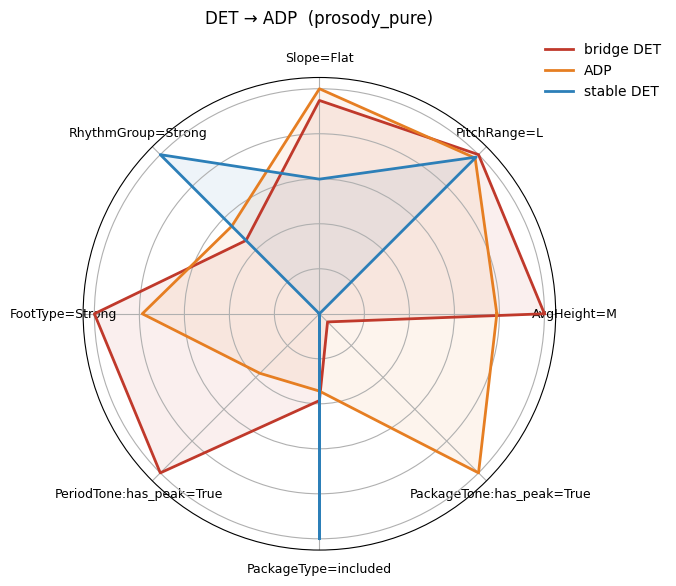

,AvgHeight=M,PitchRange=L,Slope=Flat,RhythmGroup=Strong,FootType=Strong,PeriodTone:has_peak=True,PackageType=included,PackageTone:has_peak=True
group,,,,,,,,
bridge DET,0.040746,0.507824,0.792186,0.345734,0.242439,0.048635,0.192878,0.000258
ADP,0.032129,0.496969,0.835662,0.413012,0.190819,0.018191,0.171792,0.005034
stable DET,0.000000,0.500000,0.500000,0.750000,0.000000,0.000000,0.500000,0.000000


In [153]:
spider_for_overlap("DET", "ADP")